# Numerical Experiments from Estimating Distributions with Failure Rate Properties from Noisy Quantile Data

This notebook reproduces the Numerical Experiments section from Estimating Distributions with Failure Rate Properties from Noisy Quantile Data by Chan, Chen, Fernandes, and Maaz (2026).


## Setup

Defines all imports, global constants, ground-truth distributions, and the shared error helper used by every figure.

**Key design decisions:**
- `DISTRIBUTIONS` is the single source of truth for all four ground-truth CDFs. Every experiment loops over it, so adding or removing a distribution requires changing only this dict.
- `TruncatedDist` wraps any scipy distribution and normalizes it to $[l, u]$, enforcing $F(l) = 0$ and $F(u) = 1$ exactly via $\tilde{F}(x) = (F_\text{base}(x) - F_\text{base}(l)) / (F_\text{base}(u) - F_\text{base}(l))$.
- `calculate_error_for_params` evaluates $\|F_0 - \hat{F}\|$ on a dense 2,000-point numpy grid rather than symbolically, which is faster and works for all distribution types without requiring a sympy CDF.

In [19]:
import numpy as np
from scipy.stats import beta as beta_dist, truncnorm, gamma as gamma_dist, weibull_min
from fitting import fit_cdf
import sympy as sp
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import time
import os
from matplotlib.ticker import FormatStrFormatter
import winsound

plt.rcParams.update({
    'axes.labelsize':  22,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18,
})

os.makedirs('numerical_results', exist_ok=True)

# x_sym is needed to lambdify the sympy Piecewise CDF returned by fit_cdf for numpy evaluation
x_sym = sp.Symbol('x')
l, u  = 0, 1

class TruncatedDist:
    """Wraps a scipy distribution, normalizing its CDF and PDF to the support [l, u].

    Guarantees F(l) = 0 and F(u) = 1 exactly via:
        F_trunc(x) = (F_base(x) - F_base(l)) / (F_base(u) - F_base(l))
    Needed because distributions like Gamma and Weibull have support wider than [0, 1].
    """
    def __init__(self, base_dist, l, u):
        self._base = base_dist
        self.l, self.u = l, u
        self._Fl = base_dist.cdf(l)   # pre-computed once; reused for every cdf/pdf call
        self._Fu = base_dist.cdf(u)

    def cdf(self, x):
        x = np.asarray(x, dtype=float)
        return np.clip((self._base.cdf(x) - self._Fl) / (self._Fu - self._Fl), 0.0, 1.0)

    def pdf(self, x):
        x = np.asarray(x, dtype=float)
        # Divide by the normalizing mass (F_base(u) - F_base(l)); zero outside [l, u]
        raw = self._base.pdf(x) / (self._Fu - self._Fl)
        return np.where((x >= self.l) & (x <= self.u), raw, 0.0)

# Single source of truth for all ground-truth CDFs used in Figures 2, 3, and 5.
# Adding or removing a distribution only requires changing this dict.
DISTRIBUTIONS = {
    'beta': {
        'label': r'Beta$(3,\,5)$',
        'dist':  beta_dist(3, 5),
        'suffix': 'beta_a3_b5',
    },
    'truncnorm': {
        'label': r'TruncNormal$(\mu{=}0.5,\;\sigma{=}0.10)$',
        'dist':  truncnorm((l - 0.5) / 0.10, (u - 0.5) / 0.10, loc=0.5, scale=0.10),
        'suffix': 'truncnorm_mu05_sig01',
    },
    'truncgamma': {
        # mode = (α-1)·θ = 9·0.05 = 0.45,  mean = α·θ = 10·0.05 = 0.50
        'label': r'TruncGamma$(\alpha{=}10,\;\theta{=}0.05)$',
        'dist':  TruncatedDist(gamma_dist(10, scale=0.05), l, u),
        'suffix': 'truncgamma_sh10_sc005',
    },
    'truncweibull': {
        # mode = λ·((k-1)/k)^(1/k) = 0.5·(4/5)^(1/5) ≈ 0.48,  mean ≈ 0.45
        'label': r'TruncWeibull$(k{=}5,\;\lambda{=}0.5)$',
        'dist':  TruncatedDist(weibull_min(5, scale=0.5), l, u),
        'suffix': 'truncweibull_sh5_sc05',
    },
}

# Pre-allocated once and reused in every calculate_error_for_params call to avoid repeated linspace allocations
_x_fine = np.linspace(l, u, 2000)

def calculate_error_for_params(n_i, delta, interpolation_method, dist):
    """Fit Algorithm 1 for one (n_i, delta, dist) setting; return L-inf error.

    Uses a dense numpy grid for L-inf evaluation rather than symbolic optimization
    (compute_l_inf), which is faster and works for all distribution types without
    requiring a sympy CDF expression.
    """
    eps      = 1e-6
    x_knots  = np.arange(delta, u - eps, delta)   # interior knots; eps avoids including u exactly
    true_p   = dist.cdf(x_knots)                   # true CDF at knot positions (used as Binomial p)
    n_trials = n_i * np.ones_like(x_knots, dtype=int)
    y_samples = np.random.binomial(n_trials, true_p)   # simulate observed counts

    fitted = fit_cdf(x_knots, n_trials, y_samples, l, u, interpolation_method)
    if fitted is None:
        return np.nan
    try:
        fn = sp.lambdify(x_sym, fitted, 'numpy')
        # fit_cdf returns 1 - exp(t(x)); near u, t → -50 → exp overflows to 0 in numpy — suppress warnings
        with np.errstate(invalid='ignore', over='ignore'):
            vals = fn(_x_fine)
        vals = np.where(np.isfinite(vals), vals, 1.0)   # overflow near u means F ≈ 1
        return float(np.max(np.abs(np.clip(vals, 0.0, 1.0) - dist.cdf(_x_fine))))
    except Exception:
        return np.nan

def _l_inf_step_dist(x_nc, F_nc, dist):
    """L-inf between a step CDF (from fit_cdf_nonconvex) and the true dist CDF.

    The step CDF is constant on each interval (x_nc[i], x_nc[i+1]), so the worst-case
    error on that interval is the max of the absolute gaps at both endpoints.
    """
    step_vals  = F_nc[:-1]
    true_left  = dist.cdf(x_nc[:-1])
    true_right = dist.cdf(x_nc[1:])
    return float(np.max(np.maximum(np.abs(step_vals - true_left), np.abs(step_vals - true_right))))

### Distribution Overview

Plots the PDF (top row) and CDF (bottom row) for each ground-truth distribution on $[l, u] = [0, 1]$. Run this cell first to confirm that each distribution has the intended shape and adequate mass in the interior of $[0, 1]$ before launching the expensive Monte Carlo experiments.

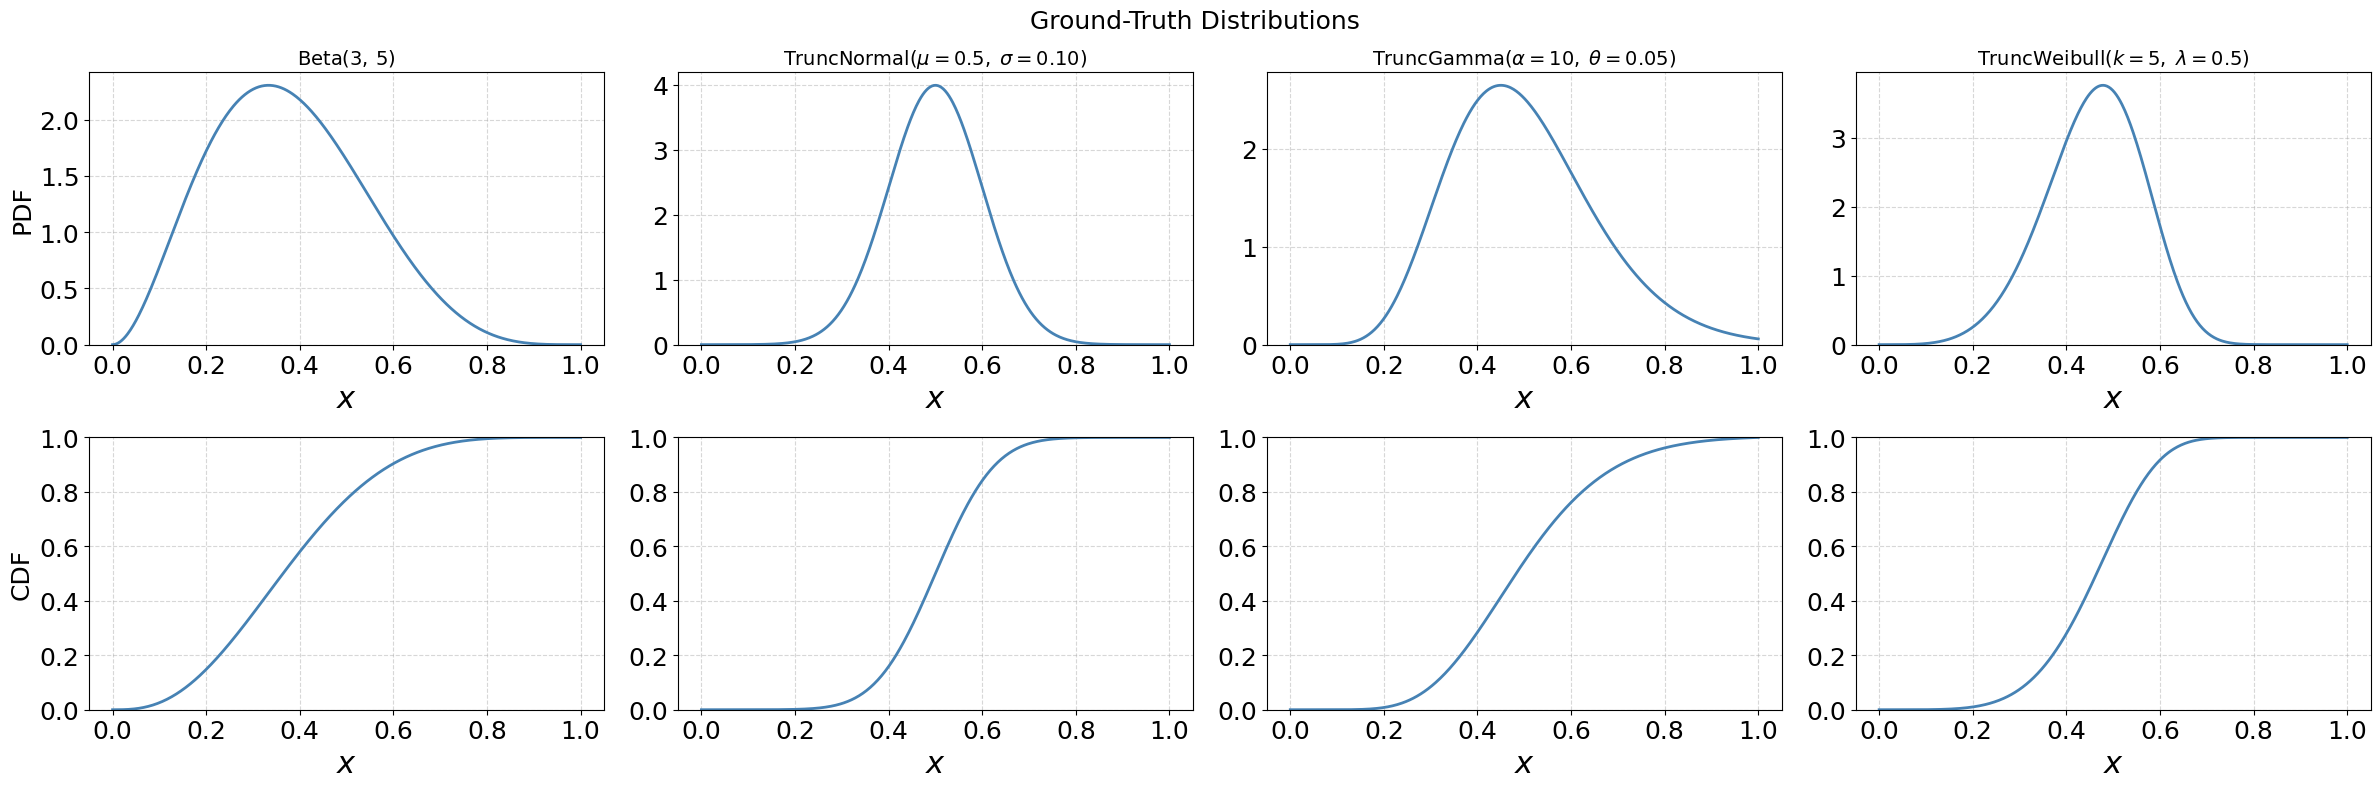

In [20]:
# Sanity check: verify each distribution has the intended shape on [0, 1] before running experiments.
# PDF (top row) shows modality and skewness; CDF (bottom row) confirms F(0) = 0 and F(1) = 1.
x_plot = np.linspace(l, u, 500)

fig, axes = plt.subplots(2, len(DISTRIBUTIONS), figsize=(6 * len(DISTRIBUTIONS), 8))

for j, (dist_key, dist_cfg) in enumerate(DISTRIBUTIONS.items()):
    dist     = dist_cfg['dist']
    cdf_vals = dist.cdf(x_plot)
    pdf_vals = dist.pdf(x_plot)

    ax_pdf = axes[0, j]
    ax_pdf.plot(x_plot, pdf_vals, color='steelblue', linewidth=2)
    ax_pdf.set_title(dist_cfg['label'], fontsize=14)
    ax_pdf.set_xlabel(r'$x$')
    ax_pdf.set_ylim(bottom=0)
    ax_pdf.grid(True, ls='--', alpha=0.5)

    ax_cdf = axes[1, j]
    ax_cdf.plot(x_plot, cdf_vals, color='steelblue', linewidth=2)
    ax_cdf.set_xlabel(r'$x$')
    ax_cdf.set_ylim(0, 1)
    ax_cdf.grid(True, ls='--', alpha=0.5)

axes[0, 0].set_ylabel('PDF', fontsize=18)
axes[1, 0].set_ylabel('CDF', fontsize=18)

plt.suptitle('Ground-Truth Distributions', fontsize=18)
plt.tight_layout()
plt.savefig('results/plots/distributions_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## Empirical Convergence Rates

Validates the two-component error decomposition from Theorem 2 by varying one quantity at a time:

- **Panel (a) — estimation error:** fix $k = 20$ equidistant knots so that interpolation error is negligible, and increase $n_i$. Corollary 1 predicts $\|F_0 - \hat{F}\| = O_p(1/\sqrt{n_i})$.
- **Panel (b) — interpolation error:** fix $n_i = 100{,}000$ so that statistical noise is negligible, and increase $k$. Corollary 2 (equidistant knots) predicts $O(1/k^2)$ for piecewise-linear and $O(1/k^3)$ for Schumaker.

Each point is averaged over 100 runs; shaded bands show $\pm 1$ standard error.

### Panel (a) — Estimation Error vs $n_i$

Fix $k = 20$ equidistant knots (so $\Delta = 1/21$ is small and interpolation error is negligible) and vary $n_i \in \{100, 500, \ldots, 100{,}000\}$. Corollary 1 (equal allocation, fixed $k$) predicts $\|\boldsymbol{\tau}_0 - \hat{\boldsymbol{\tau}}\| = O_p(1/\sqrt{n_i})$, which translates to the same rate for $\|F_0 - \hat{F}\|$.

The experiment loops over all four distributions in `DISTRIBUTIONS`. Figure 2(a) shows the standalone Beta result; the appendix 1×3 shows the remaining three. Results are saved to `numerical_results/data/estimation_error_{suffix}.npz` for each distribution.

#### Computation

Sweeps $n_i \in \{100, 500, 2000, \ldots, 100{,}000\}$ with $k = 20$ fixed, averaging `num_runs` Monte Carlo replications per value. Loops over all four distributions and saves one `.npz` file per distribution to `numerical_results/data/estimation_error_{suffix}.npz`.

In [ ]:
np.random.seed(1)

# k=20 equidistant knots → Δ=1/21≈0.048; interpolation error ≈ O(1/k²)≈0.0025,
# well below estimation errors even at the smallest n_i=100, so estimation error dominates
k_fixed      = 20
delta_fixed  = (u - l) / (k_fixed + 1)   # Δ = 1/(k+1): spacing of k equidistant interior knots on [l, u]
n_i_sequence = [100, 500, 2000, 4000, 8000, 12000, 20000,
                30000, 40000, 50000, 60000, 70000, 80000, 90000, 100000]
num_runs = 100    # 100 for paper results
methods  = ['linear', 'schumaker']

t_start = time.perf_counter()
for dist_key, dist_cfg in DISTRIBUTIONS.items():
    # Per-method accumulators for mean error, sample std, and n_i values with ≥1 successful run
    results      = {m: [] for m in methods}
    results_std  = {m: [] for m in methods}
    valid_n_is   = {m: [] for m in methods}

    for method in methods:
        avg_errors, std_errors, temp_n_is = [], [], []
        for n_i in tqdm(n_i_sequence, desc=f'{dist_key}/{method}'):
            errors = [calculate_error_for_params(n_i, delta_fixed, method, dist_cfg['dist'])
                      for _ in range(num_runs)]
            errors = [e for e in errors if not np.isnan(e)]   # drop failed runs (infeasible LP)
            if errors:
                avg_errors.append(np.mean(errors))
                std_errors.append(np.std(errors, ddof=1))   # Bessel-corrected sample std
                temp_n_is.append(n_i)
        results[method]     = np.array(avg_errors)
        results_std[method] = np.array(std_errors)
        valid_n_is[method]  = np.array(temp_n_is)

    suffix = dist_cfg['suffix']
    np.savez(f'results/data/estimation_error_{suffix}.npz',
        k_fixed=k_fixed, num_runs=num_runs,
        linear_n_is=valid_n_is['linear'],       linear_errors=results['linear'],
        linear_errors_std=results_std['linear'],
        schumaker_n_is=valid_n_is['schumaker'], schumaker_errors=results['schumaker'],
        schumaker_errors_std=results_std['schumaker'])
    print(f'Saved estimation_error_{suffix}.npz')

print(f'Total time: {time.perf_counter() - t_start:.1f}s')

#### Plotting

Loads `numerical_results/data/estimation_error_{suffix}.npz` for each distribution; can be run independently. Produces two outputs:
- **Figure 2(a):** standalone plot for Beta$(3,5)$, saved to `estimation_error_beta_a3_b5.png`.
- **Appendix (a):** three standalone figures for TruncNormal, TruncGamma, TruncWeibull, saved to `estimation_error_{suffix}.png` for each.

The theoretical $O(1/\sqrt{n_i})$ reference curve is anchored at the first empirical data point.

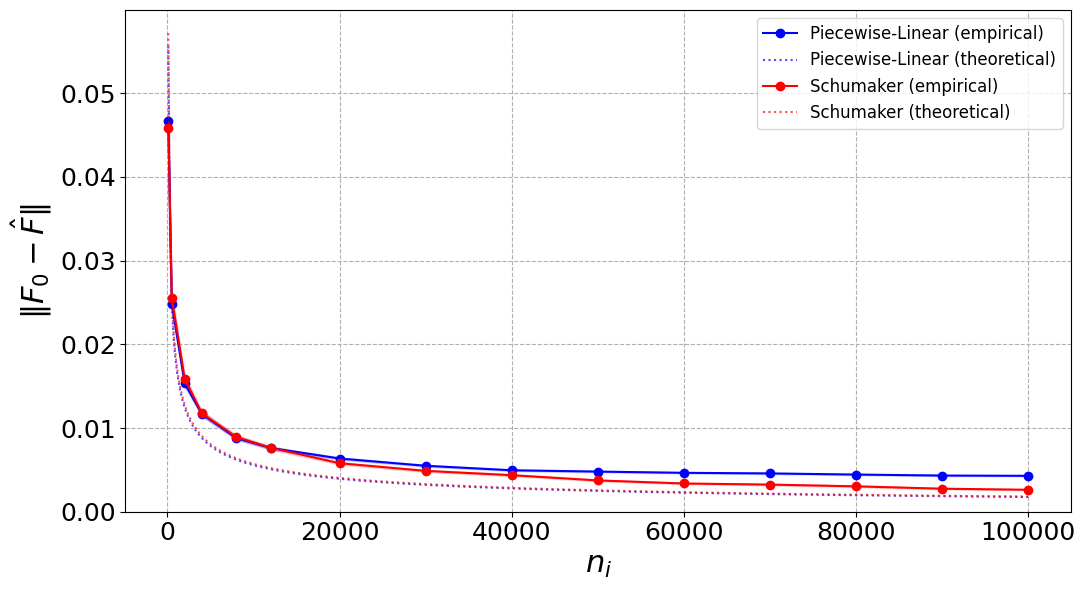

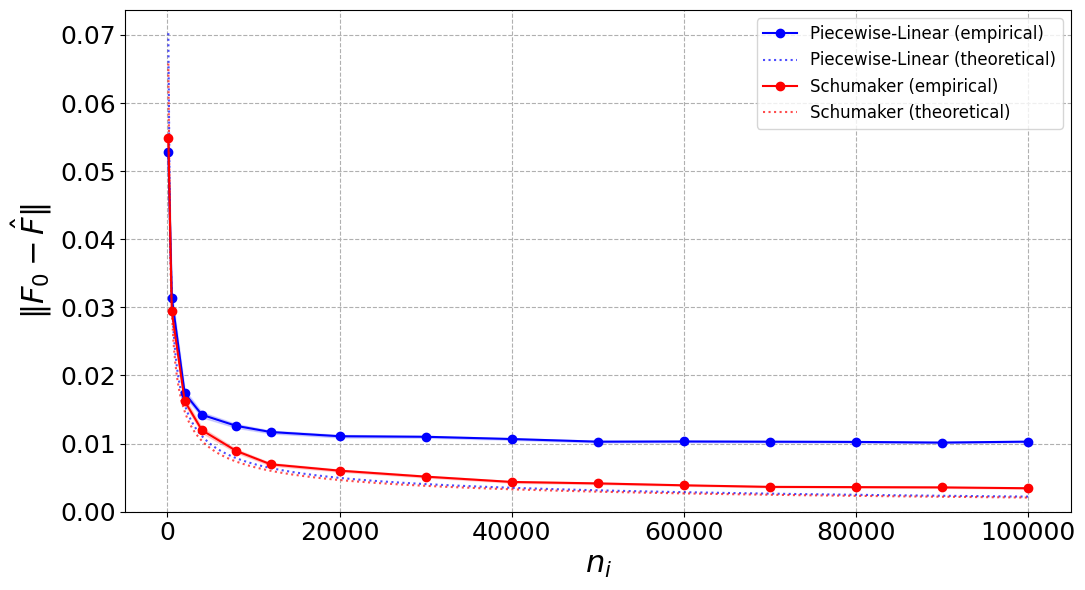

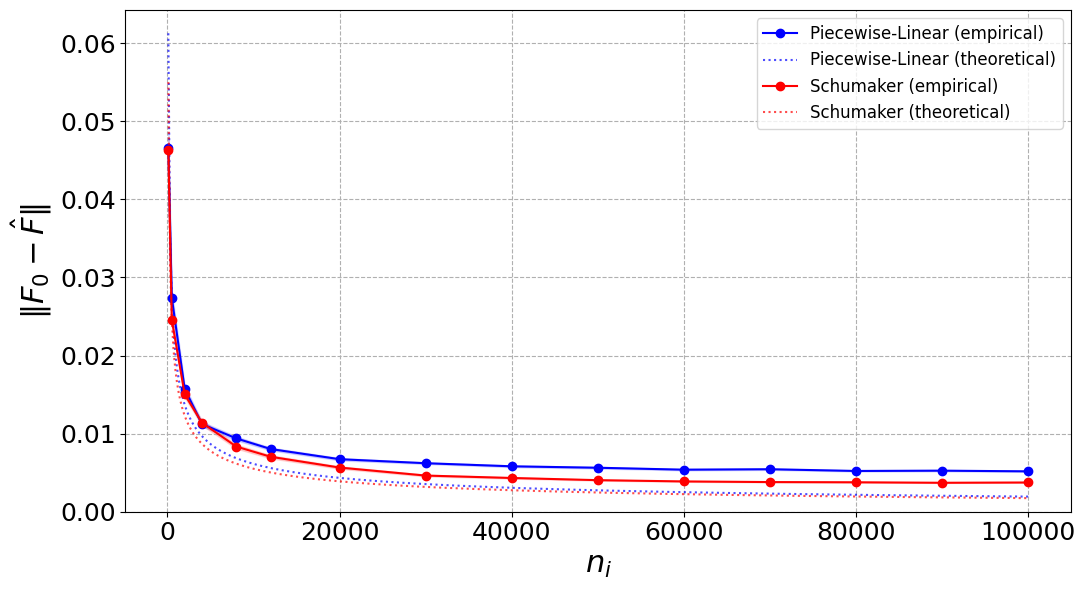

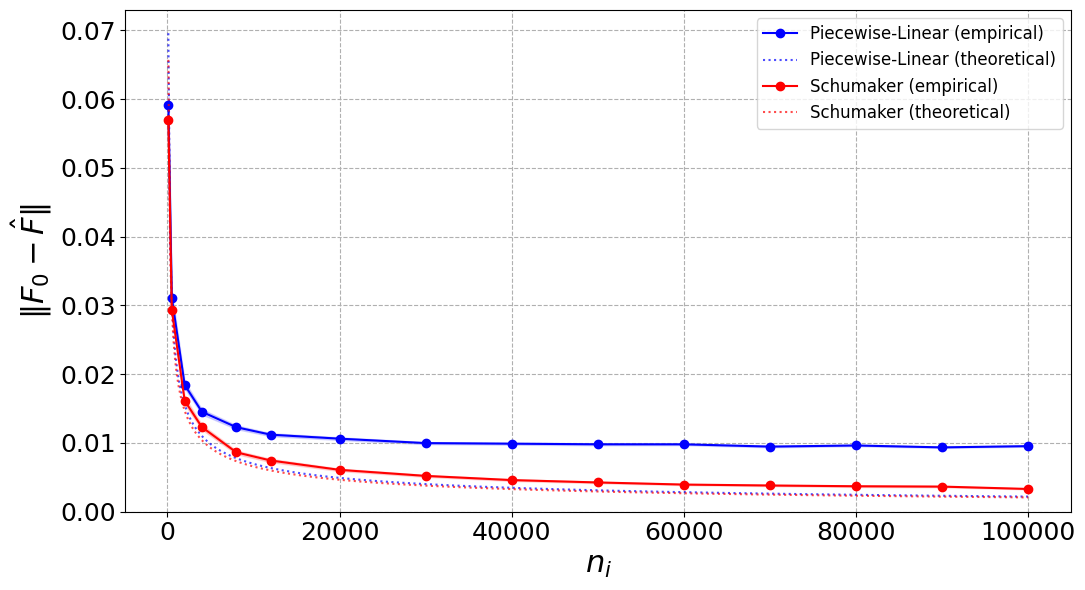

In [22]:
colors = {'linear': 'blue', 'schumaker': 'red'}
labels = {'linear': 'Piecewise-Linear', 'schumaker': 'Schumaker'}

def plot_estimation_error(ax, dist_cfg):
    suffix    = dist_cfg['suffix']
    data      = np.load(f'results/data/estimation_error_{suffix}.npz')
    num_runs_ = int(data['num_runs'])
    valid_n_is  = {'linear': data['linear_n_is'],         'schumaker': data['schumaker_n_is']}
    results     = {'linear': data['linear_errors'],     'schumaker': data['schumaker_errors']}
    results_std = {'linear': data['linear_errors_std'], 'schumaker': data['schumaker_errors_std']}

    for method in ['linear', 'schumaker']:
        n_is   = valid_n_is[method].astype(float)
        errors = results[method]
        ses    = results_std[method] / np.sqrt(num_runs_)   # standard error of the mean

        ax.plot(n_is, errors, marker='o', linestyle='-',
                label=labels[method] + ' (empirical)', color=colors[method])
        ax.fill_between(n_is, errors - ses, errors + ses, alpha=0.15, color=colors[method])   # ±1 SE band

        # Anchor the O(1/√n_i) reference at index 1 (second point): skips the noisiest
        # first observation while staying early enough to span most of the n_i range
        C       = errors[1] * np.sqrt(n_is[1])
        n_i_ref = np.linspace(n_is[0], n_is[-1], 500)
        ax.plot(n_i_ref, C / np.sqrt(n_i_ref), linestyle=':', color=colors[method], alpha=0.7,
                label=labels[method] + r' (theoretical)')

    ax.set_xlabel(r'$n_i$')
    ax.set_ylabel(r'$\|F_0 - \hat{F}\|$')
    ax.legend(fontsize=12)
    ax.grid(True, ls='--')
    ax.set_ylim(bottom=0)

# --- Figure 2(a): Beta standalone ---
fig, ax = plt.subplots(figsize=(11, 6))
plot_estimation_error(ax, DISTRIBUTIONS['beta'])
# ax.set_title(DISTRIBUTIONS['beta']['label'], fontsize=18)
plt.tight_layout()
plt.savefig(f'results/plots/estimation_error_{DISTRIBUTIONS["beta"]["suffix"]}.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Appendix (a): TruncNormal, TruncGamma, TruncWeibull — standalone figures ---
appendix_dists = {k: v for k, v in DISTRIBUTIONS.items() if k != 'beta'}
for dist_key, dist_cfg in appendix_dists.items():
    fig, ax = plt.subplots(figsize=(11, 6))
    plot_estimation_error(ax, dist_cfg)
    plt.tight_layout()
    plt.savefig(f'results/plots/estimation_error_{dist_cfg["suffix"]}.png', dpi=150, bbox_inches='tight')
    plt.show()

### Panel (b) — Interpolation Error vs $k$

Fix $n_i = 100{,}000$ and vary $k \in \{4, 5, \ldots, 20\}$. With equidistant knot spacing $\Delta = 1/(k+1)$, the interpolation error dominates and scales as $O(1/k^p)$, with $p = 2$ (piecewise-linear) and $p = 3$ (Schumaker), as predicted by Corollary 2.

The experiment loops over all four distributions in `DISTRIBUTIONS`. Figure 2(b) shows the standalone Beta result; the appendix 1×3 shows the remaining three. Results are saved to `numerical_results/data/interpolation_error_{suffix}.npz` for each distribution.

#### Computation

Sweeps $k \in \{4, 5, \ldots, 20\}$ with $n_i = 100{,}000$ fixed, averaging `num_runs` Monte Carlo replications per value. Loops over all four distributions and saves one `.npz` file per distribution to `numerical_results/data/interpolation_error_{suffix}.npz`.

In [ ]:
np.random.seed(1)

# n_i=100,000 → estimation error ≈ O(1/√n_i) ≈ 0.003, negligible relative to interpolation
# errors at small k, so interpolation error dominates throughout the k sweep
n_i_fixed  = 100_000
k_sequence = list(range(4, 21, 1))   # k ∈ {4, ..., 20}; equidistant spacing Δ=1/(k+1) on [0,1]
num_runs   = 100    # 100 for paper results
methods    = ['linear', 'schumaker']

t_start = time.perf_counter()
for dist_key, dist_cfg in DISTRIBUTIONS.items():
    results      = {m: [] for m in methods}
    results_std  = {m: [] for m in methods}
    valid_ks     = {m: [] for m in methods}

    for method in methods:
        avg_errors, std_errors, temp_ks = [], [], []
        for k in tqdm(k_sequence, desc=f'{dist_key}/{method}'):
            delta  = (u - l) / (k + 1)   # Δ = 1/(k+1): spacing of k equidistant interior knots
            errors = [calculate_error_for_params(n_i_fixed, delta, method, dist_cfg['dist'])
                      for _ in range(num_runs)]
            errors = [e for e in errors if not np.isnan(e)]   # drop failed runs (infeasible LP)
            if errors:
                avg_errors.append(np.mean(errors))
                std_errors.append(np.std(errors, ddof=1))   # Bessel-corrected sample std
                temp_ks.append(k)
        results[method]     = np.array(avg_errors)
        results_std[method] = np.array(std_errors)
        valid_ks[method]    = np.array(temp_ks)

    suffix = dist_cfg['suffix']
    np.savez(f'results/data/interpolation_error_{suffix}.npz',
        n_i_fixed=n_i_fixed, num_runs=num_runs,
        linear_ks=valid_ks['linear'],       linear_errors=results['linear'],
        linear_errors_std=results_std['linear'],
        schumaker_ks=valid_ks['schumaker'], schumaker_errors=results['schumaker'],
        schumaker_errors_std=results_std['schumaker'])
    print(f'Saved interpolation_error_{suffix}.npz')

print(f'Total time: {time.perf_counter() - t_start:.1f}s')

#### Plotting

Loads `numerical_results/data/interpolation_error_{suffix}.npz` for each distribution; can be run independently. Produces two outputs:
- **Figure 2(b):** standalone plot for Beta$(3,5)$, saved to `interpolation_error_beta.png`.
- **Appendix (b):** three standalone figures for TruncNormal, TruncGamma, TruncWeibull, saved to `interpolation_error_{suffix}.png` for each.

The theoretical $O(1/k^p)$ reference curve ($p=2$ linear, $p=3$ Schumaker) is anchored at the first data point ($k=4$), where the asymptotic rate is expected to hold.

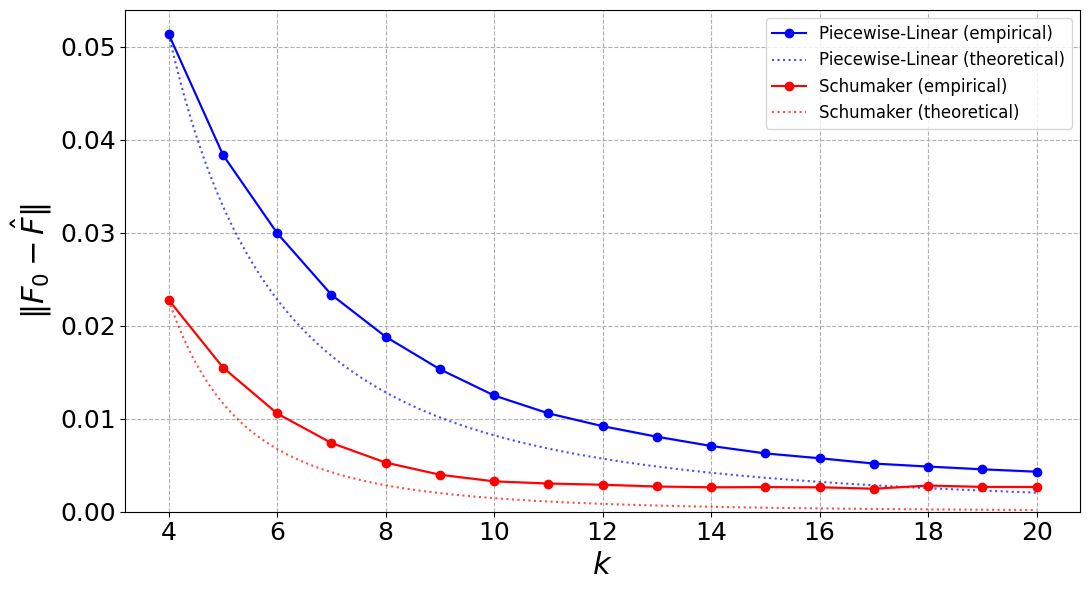

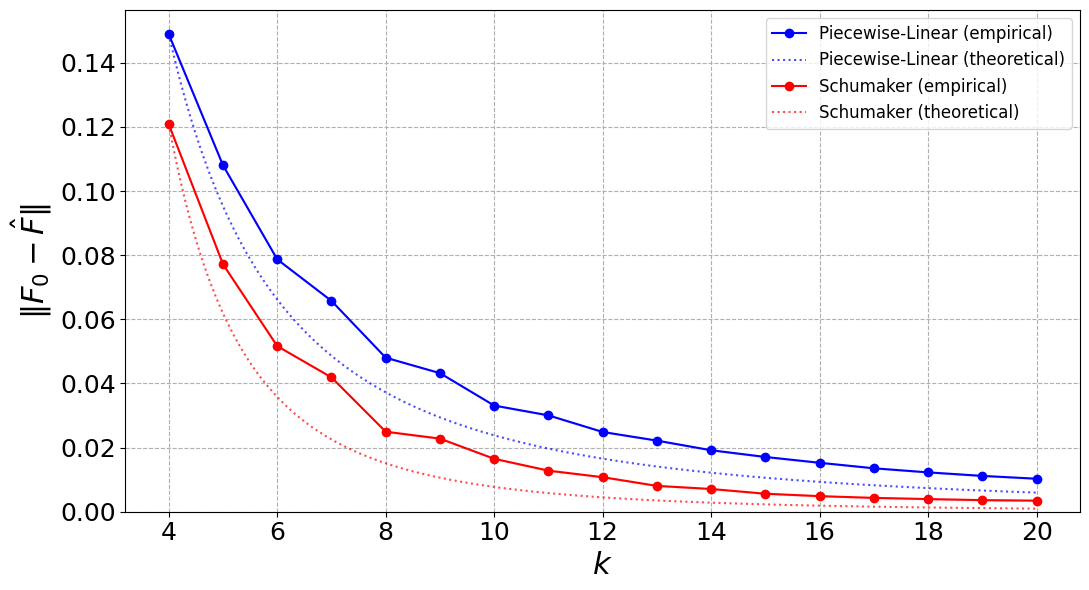

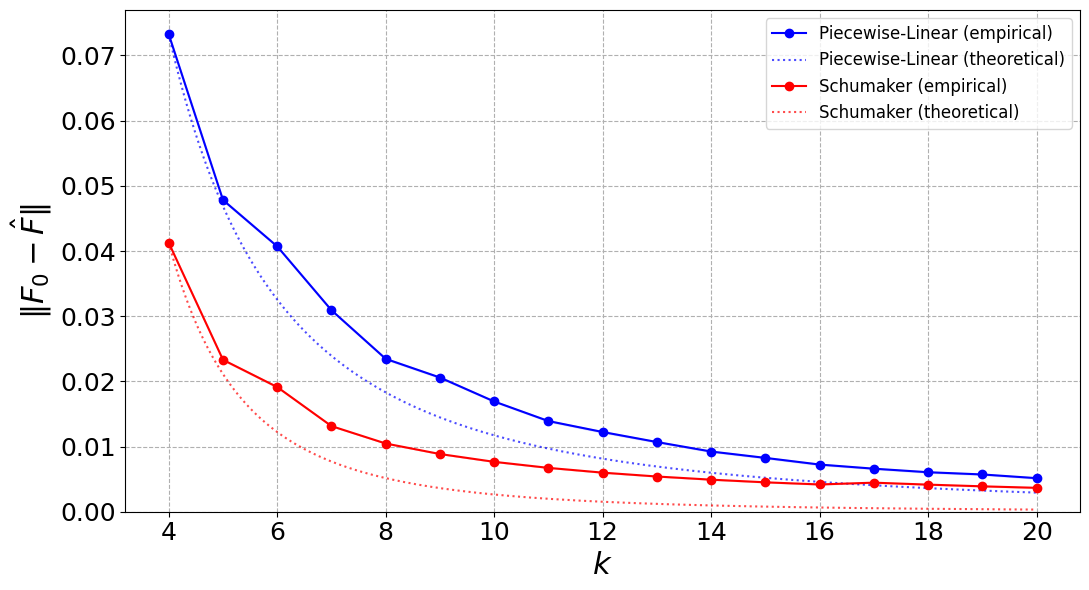

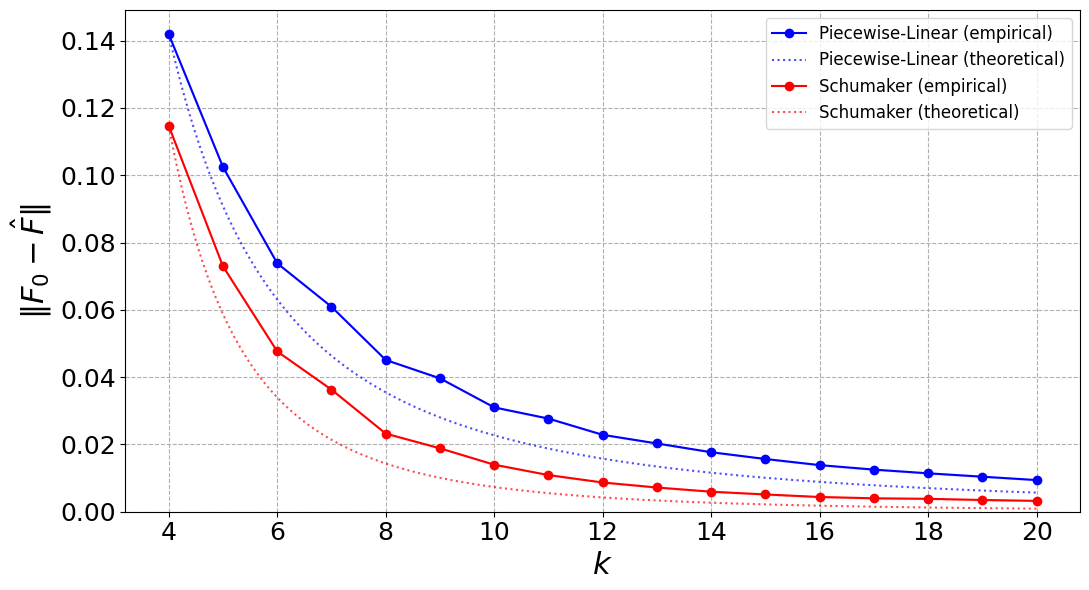

In [23]:
colors = {'linear': 'blue', 'schumaker': 'red'}
powers = {'linear': 2, 'schumaker': 3}   # Corollary 2 rates: O(Δ²) ≡ O(1/k²) linear, O(Δ³) ≡ O(1/k³) Schumaker
labels = {'linear': 'Piecewise-Linear', 'schumaker': 'Schumaker'}

def plot_interpolation_error(ax, dist_cfg):
    suffix    = dist_cfg['suffix']
    data      = np.load(f'results/data/interpolation_error_{suffix}.npz')
    num_runs_ = int(data['num_runs'])
    valid_ks    = {'linear': data['linear_ks'],         'schumaker': data['schumaker_ks']}
    results     = {'linear': data['linear_errors'],     'schumaker': data['schumaker_errors']}
    results_std = {'linear': data['linear_errors_std'], 'schumaker': data['schumaker_errors_std']}

    for method in ['linear', 'schumaker']:
        ks     = valid_ks[method].astype(float)
        errors = results[method]
        ses    = results_std[method] / np.sqrt(num_runs_)   # standard error of the mean

        ax.plot(ks, errors, marker='o', linestyle='-',
                label=labels[method] + ' (empirical)', color=colors[method])
        ax.fill_between(ks, errors - ses, errors + ses, alpha=0.15, color=colors[method])   # ±1 SE band

        # Anchor the O(1/k^p) reference at the first point (index 0): the k range starts at k=4,
        # where the asymptotic rate already holds well
        p     = powers[method]
        C     = errors[0] * ks[0] ** p
        k_ref = np.linspace(ks[0], ks[-1], 200)
        ax.plot(k_ref, C / k_ref ** p, linestyle=':', color=colors[method], alpha=0.7,
                label=labels[method] + rf' (theoretical)')

    ax.set_xlabel(r'$k$')
    ax.set_ylabel(r'$\|F_0 - \hat{F}\|$')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f'{val:.2f}'))
    ax.legend(fontsize=12)
    ax.grid(True, ls='--')
    ax.set_ylim(bottom=0)

# --- Figure 2(b): Beta standalone ---
fig, ax = plt.subplots(figsize=(11, 6))
plot_interpolation_error(ax, DISTRIBUTIONS['beta'])
# ax.set_title(DISTRIBUTIONS['beta']['label'], fontsize=18)
plt.tight_layout()
plt.savefig(f'results/plots/interpolation_error_{DISTRIBUTIONS["beta"]["suffix"]}.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Appendix (b): TruncNormal, TruncGamma, TruncWeibull — standalone figures ---
appendix_dists = {k: v for k, v in DISTRIBUTIONS.items() if k != 'beta'}
for dist_key, dist_cfg in appendix_dists.items():
    fig, ax = plt.subplots(figsize=(11, 6))
    plot_interpolation_error(ax, dist_cfg)
    plt.tight_layout()
    plt.savefig(f'results/plots/interpolation_error_{dist_cfg["suffix"]}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Optimal Knot Allocation at Fixed Total Budget

Investigates the tradeoff between estimation and interpolation error when the total data budget $N$ is fixed and observations are allocated equally across $k$ equidistant knots, so each knot receives $\lfloor N/k \rfloor$ trials.

- **More knots** reduces interpolation error (knots are closer together) but increases estimation error (fewer samples per knot).
- **Fewer knots** reduces estimation error but increases interpolation error.
- Section 4.1 shows the optimal $k^*$ balances the two terms and grows slowly with $N$.

We repeat the experiment for $F_0 \sim \mathrm{Beta}(3, b)$ with $b \in \{5, 8, 15\}$, covering a range of right-skewed distributions.

### True Distributions

The three ground-truth CDFs $F_0 \sim \mathrm{Beta}(3, b)$ for $b \in \{5, 8, 15\}$ are plotted below. As $b$ increases the distribution becomes more right-skewed and the bulk of the mass shifts toward 0. Cross-hair markers show equidistant knot positions for $k \in \{2, 3, 4\}$.

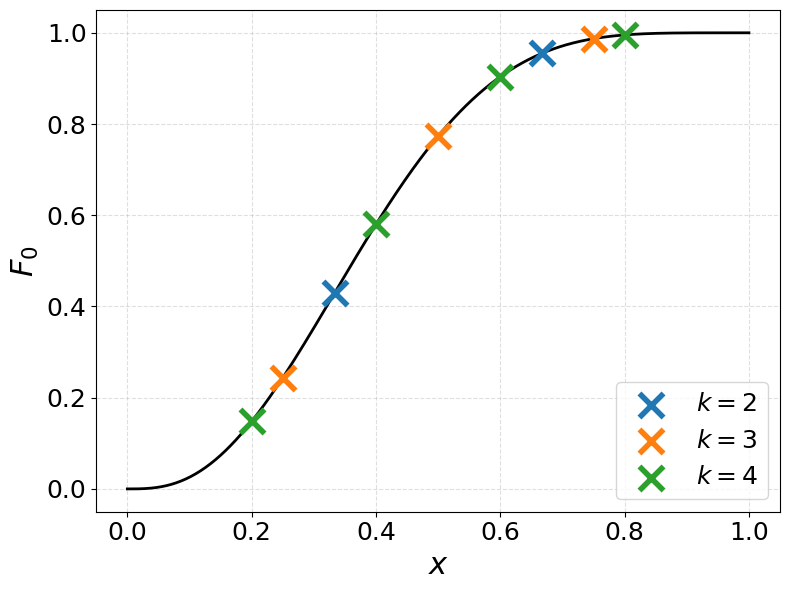

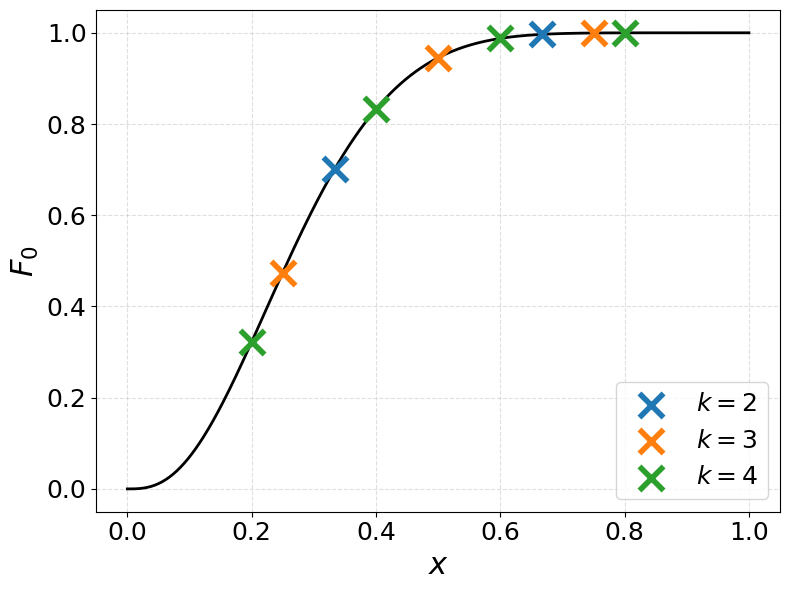

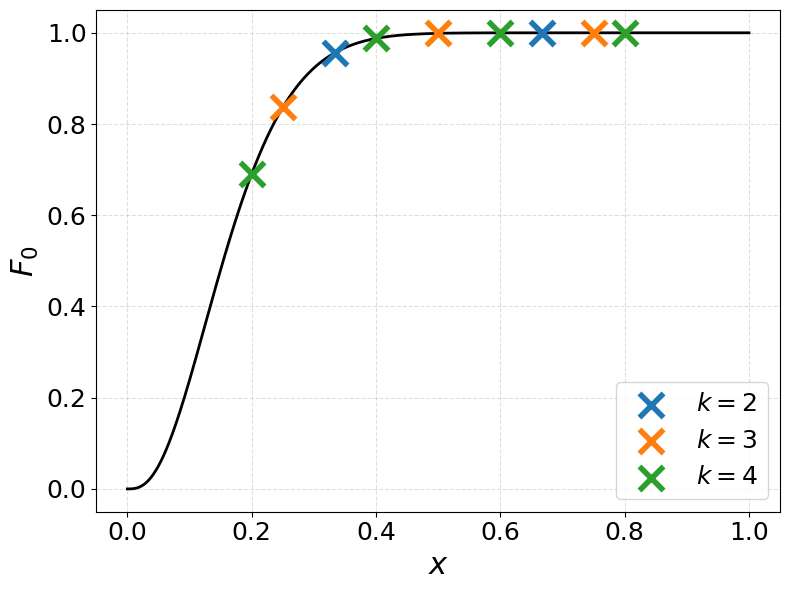

In [24]:
a=3
b_values = [5, 8, 15]

for b_val in b_values:
    fig, ax = plt.subplots(figsize=(8, 6))
    x_fine = np.linspace(l, u, 500)
    ax.plot(x_fine, beta_dist.cdf(x_fine, a, b_val), 'black', linewidth=2)
    for k_mark in [2, 3, 4]:
        x_k = np.linspace(l, u, k_mark + 2)[1:-1]   # k equidistant interior knots, excluding l and u
        ax.scatter(x_k, beta_dist.cdf(x_k, a, b_val),
                   zorder=5, s=300, marker='x', linewidths=4, label=f'$k={k_mark}$')
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$F_0$')
    # ax.set_title(f'Beta(3, {b_val})')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(f'results/plots/beta_distribution_a3_b{b_val}.png', dpi=150)
    plt.show()

### Computation

For each $b \in \{5, 8, 15\}$, sweep $k \in \{1, \ldots, 10\}$ across total budgets $N \in \{150, 200, 250, 300, 350, 5000\}$. Each knot receives $\lfloor N/k \rfloor$ trials. Results are averaged over 100 Monte Carlo replications and saved to `numerical_results/data/knot_allocation_beta_a3_b{b}.npz`.

In [ ]:
np.random.seed(42)

a=3
b_values        = [5, 8, 15]      # Beta(3, b) ground truths to sweep
total_N_values  = [150, 200, 250, 300, 350, 5000]   # total data budgets
k_values_alloc  = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]           # knot counts to sweep
num_runs_alloc  = 100   # 100 for paper results
x_fine          = np.linspace(l, u, 2000)   # dense grid for L-inf evaluation

t_start = time.perf_counter()
for b_val in b_values:
    true_vals = beta_dist.cdf(x_fine, a, b_val)   # dense true CDF for L-inf error computation
    shape     = (len(total_N_values), len(k_values_alloc), num_runs_alloc)
    errors    = np.full(shape, np.nan)   # 3D array indexed by (total_N, k, run)

    total = len(total_N_values) * len(k_values_alloc)
    with tqdm(total=total, desc=f'Beta(3,{b_val})') as pbar:
        for ti, total_N in enumerate(total_N_values):
            for ki, k in enumerate(k_values_alloc):
                pbar.set_postfix(total_N=total_N, k=k)
                n_per_knot     = max(1, total_N // k)             # equal allocation: floor(N/k) per knot
                x_knots_alloc  = np.linspace(l, u, k + 2)[1:-1]  # k equidistant interior knots
                true_p         = beta_dist.cdf(x_knots_alloc, a, b_val)
                n_trials_alloc = n_per_knot * np.ones(k, dtype=int)
                for run_idx in range(num_runs_alloc):
                    y_samp = np.random.binomial(n_trials_alloc, true_p)   # y_i ~ Binomial(n_i, F_0(x_i))
                    fitted = fit_cdf(x_knots_alloc, n_trials_alloc, y_samp, l, u, 'schumaker')
                    fn     = sp.lambdify(x_sym, fitted, 'numpy')
                    with np.errstate(invalid='ignore', over='ignore'):
                        vals = fn(x_fine)
                    vals = np.where(np.isfinite(vals), vals, 1.0)   # replace sympy overflow near u with 1
                    errors[ti, ki, run_idx] = np.max(np.abs(np.clip(vals, 0, 1) - true_vals))
                pbar.update(1)

    np.savez(f'results/data/knot_allocation_beta_a{a}_b{b_val}.npz',
             total_N_values=total_N_values, k_values=k_values_alloc,
             num_runs=num_runs_alloc, errors=errors)
    print(f'Saved knot_allocation_a{a}_b{b_val}.npz')

print(f'Total time: {time.perf_counter() - t_start:.1f}s')

### Plotting

Results are loaded from `numerical_results/data/knot_allocation_a3_b{b}.npz` for each $b \in \{5, 8, 15\}$. Each panel shows $\|F_0 - \hat{F}\|$ vs $k$ for six total budgets $N \in \{150, 200, 250, 300, 350, 5000\}$, illustrating the U-shaped tradeoff and how the optimal $k^*$ shifts with $N$.

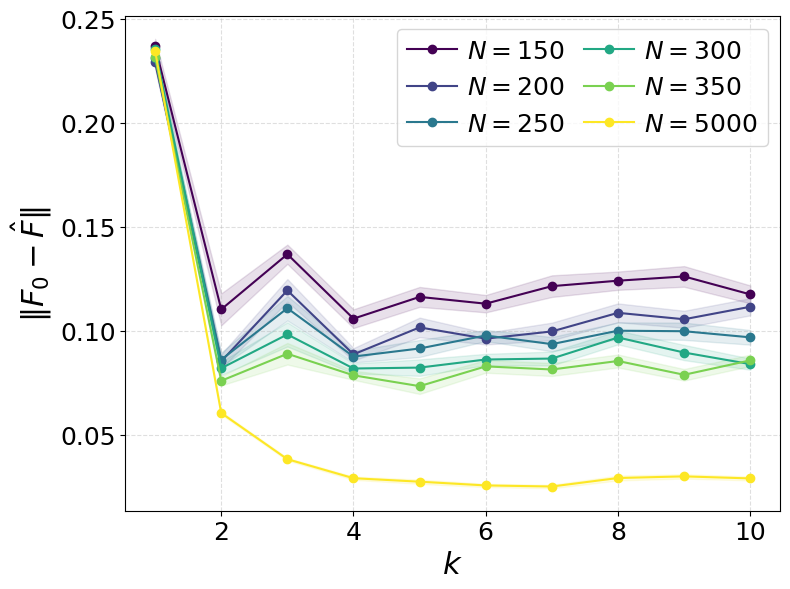

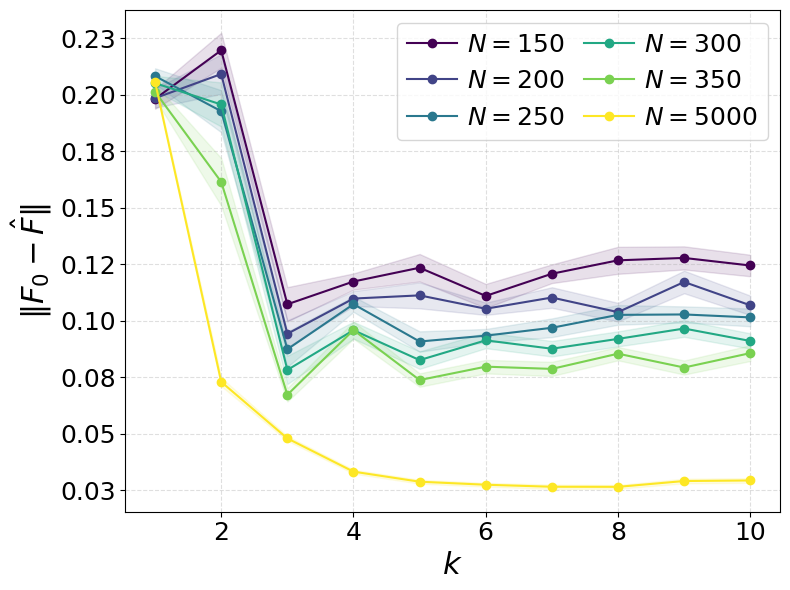

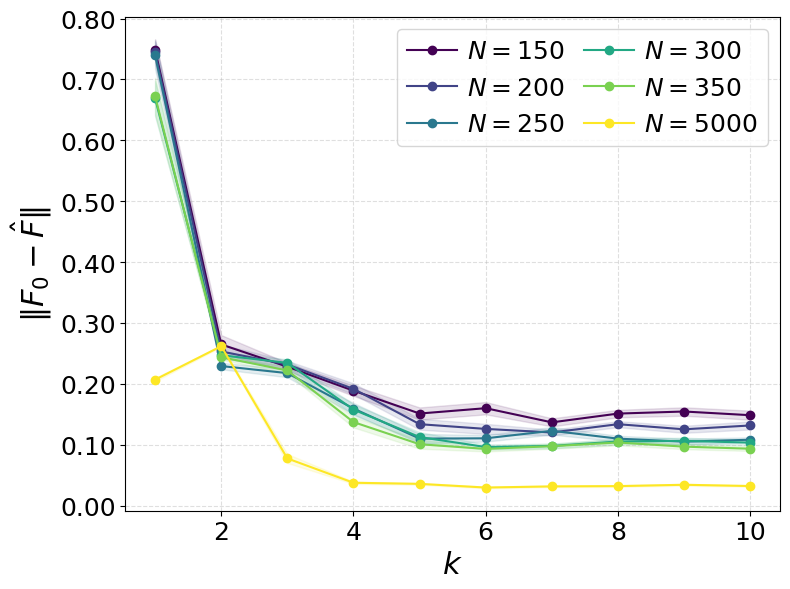

In [25]:
a = 3
b_values = [5, 8, 15]

for b_val in b_values:
    data         = np.load(f'results/data/knot_allocation_beta_a{a}_b{b_val}.npz')
    total_N_list = data['total_N_values'].tolist()
    k_list       = data['k_values'].tolist()
    num_runs_    = int(data['num_runs'])
    errors       = data['errors']   # shape (len_totalN, len_k, num_runs)

    cmap   = plt.cm.viridis
    colors = [cmap(i / max(len(total_N_list) - 1, 1)) for i in range(len(total_N_list))]

    fig, ax = plt.subplots(figsize=(8, 6))
    for ti, total_N in enumerate(total_N_list):
        with np.errstate(all='ignore'):
            y_mean = np.nanmean(errors[ti, :, :], axis=1)
            y_se   = np.nanstd( errors[ti, :, :], axis=1) / np.sqrt(num_runs_)
        ax.plot(k_list, y_mean, marker='o', color=colors[ti], label=f'$N={total_N}$')
        ax.fill_between(k_list, y_mean - y_se, y_mean + y_se, alpha=0.12, color=colors[ti])

    ax.set_xlabel(r'$k$')
    ax.set_ylabel(r'$\|F_0 - \hat{F}\|$')
    # ax.set_title(f'Beta(3, {b_val})')
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.legend(loc='upper right', ncol=2, columnspacing=0.8, handletextpad=0.4)
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.savefig(f'results/plots/knot_allocation_beta_a3_b{b_val}.png', dpi=150)
    plt.show()

### Appendix — Knot Allocation for Additional Distributions

Replicates the experiment for the three additional ground-truth distributions (Truncated Normal, Truncated Gamma, Truncated Weibull). Each panel shows $\|F_0 - \hat{F}\|$ vs $k$ across the same six total budgets $N$, using the Schumaker interpolation method.

In [ ]:
np.random.seed(0)

# Mirrors the Beta computation in b0d78ffa but uses dist.cdf() from DISTRIBUTIONS
# instead of beta_dist.cdf(), so it generalizes to TruncNormal, TruncGamma, TruncWeibull.
total_N_values  = [150, 200, 250, 300, 350, 5000]   # total data budgets to sweep
k_values_alloc  = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]   # knot counts to sweep
num_runs_alloc  = 100   # 100 for paper results
x_fine_fig3     = np.linspace(l, u, 2000)   # dense grid for L-inf evaluation

appendix_dists = {k: v for k, v in DISTRIBUTIONS.items() if k != 'beta'}

t_start = time.perf_counter()
for dist_key, dist_cfg in appendix_dists.items():
    dist      = dist_cfg['dist']
    true_vals = dist.cdf(x_fine_fig3)   # pre-compute true CDF on dense grid once per distribution
    shape     = (len(total_N_values), len(k_values_alloc), num_runs_alloc)
    errors    = np.full(shape, np.nan)   # 3D array indexed by (total_N_idx, k_idx, run_idx)

    with tqdm(total=len(total_N_values) * len(k_values_alloc), desc=dist_key) as pbar:
        for ti, total_N in enumerate(total_N_values):
            for ki, k in enumerate(k_values_alloc):
                pbar.set_postfix(total_N=total_N, k=k)
                n_per_knot     = max(1, total_N // k)             # equal allocation: ⌊N/k⌋ per knot
                x_knots_alloc  = np.linspace(l, u, k + 2)[1:-1]  # k equidistant interior knots
                true_p         = dist.cdf(x_knots_alloc)
                n_trials_alloc = n_per_knot * np.ones(k, dtype=int)
                for run_idx in range(num_runs_alloc):
                    y_samp = np.random.binomial(n_trials_alloc, true_p)   # y_i ~ Binomial(n_i, F_0(x_i))
                    fitted = fit_cdf(x_knots_alloc, n_trials_alloc, y_samp, l, u, 'schumaker')
                    fn     = sp.lambdify(x_sym, fitted, 'numpy')
                    with np.errstate(invalid='ignore', over='ignore'):
                        vals = fn(x_fine_fig3)
                    vals = np.where(np.isfinite(vals), vals, 1.0)   # replace sympy overflow near u with 1
                    errors[ti, ki, run_idx] = np.max(np.abs(np.clip(vals, 0, 1) - true_vals))
                pbar.update(1)

    suffix = dist_cfg['suffix']
    np.savez(f'results/data/knot_allocation_{suffix}.npz',
             total_N_values=total_N_values, k_values=k_values_alloc,
             num_runs=num_runs_alloc, errors=errors)
    print(f'Saved knot_allocation_{suffix}.npz')

print(f'Total time: {time.perf_counter() - t_start:.1f}s')

#### Plotting

First, plot the ground-truth distributions and the location of 2, 3, and 4 equidistant knots.

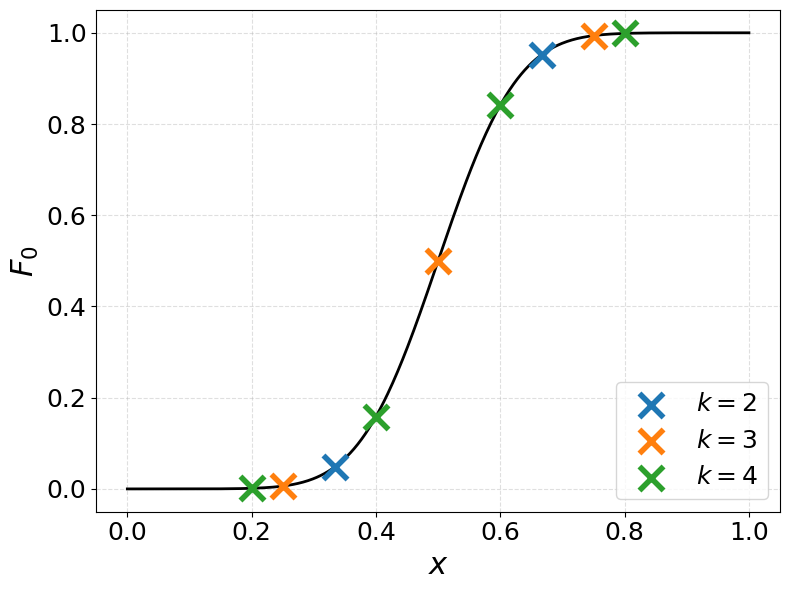

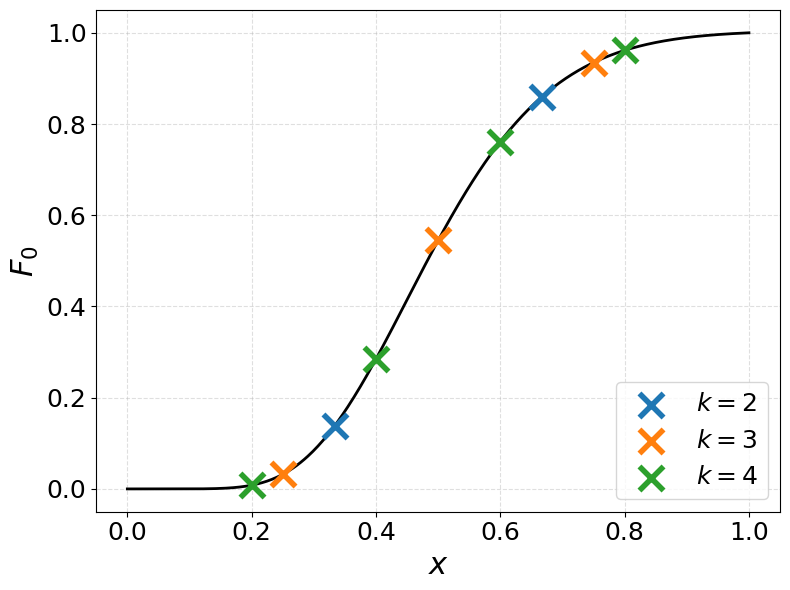

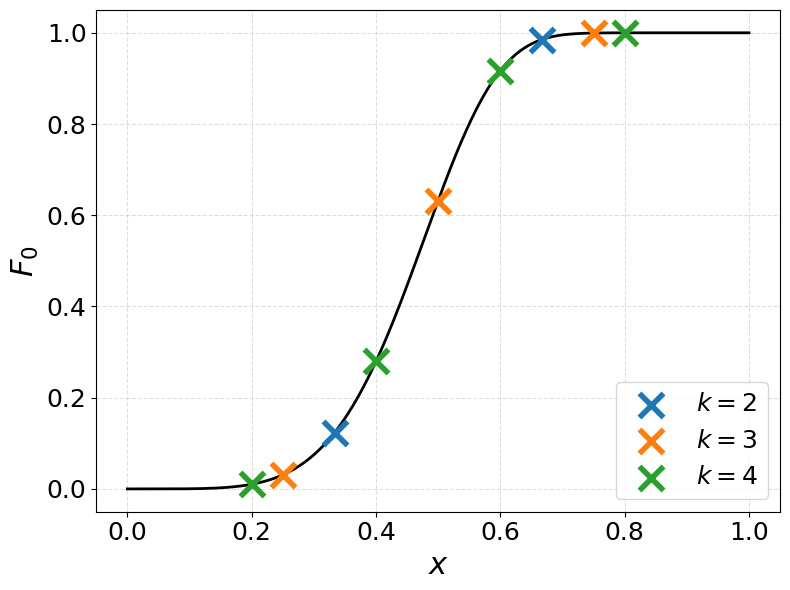

In [26]:
appendix_dists = {k: v for k, v in DISTRIBUTIONS.items() if k != 'beta'}

for dist_key, dist_cfg in appendix_dists.items():
    fig, ax = plt.subplots(figsize=(8, 6))
    x_fine = np.linspace(l, u, 500)
    dist   = dist_cfg['dist']
    ax.plot(x_fine, dist.cdf(x_fine), 'black', linewidth=2)
    for k_mark in [2, 3, 4]:
        x_k = np.linspace(l, u, k_mark + 2)[1:-1]   # k equidistant interior knots, excluding l and u
        ax.scatter(x_k, dist.cdf(x_k),
                   zorder=5, s=300, marker='x', linewidths=4, label=f'$k={k_mark}$')
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$F_0$')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(f'results/plots/distribution_{dist_cfg["suffix"]}.png', dpi=150, bbox_inches='tight')
    plt.show()

Loads the pre-computed `.npz` files from the computation cell above and produces the 1×3 appendix figure showing $\|F_0 - \hat{F}\|$ vs $k$ for each of the three additional distributions. Can be run independently of the computation cell.

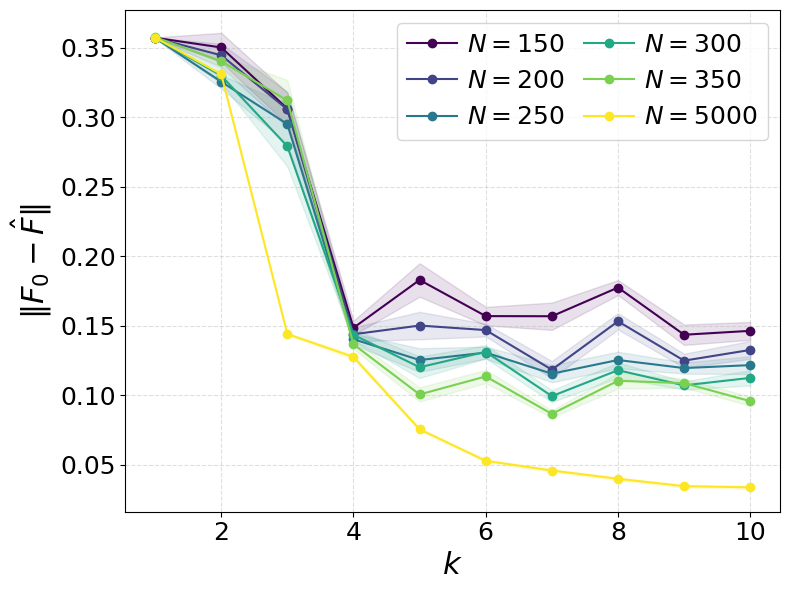

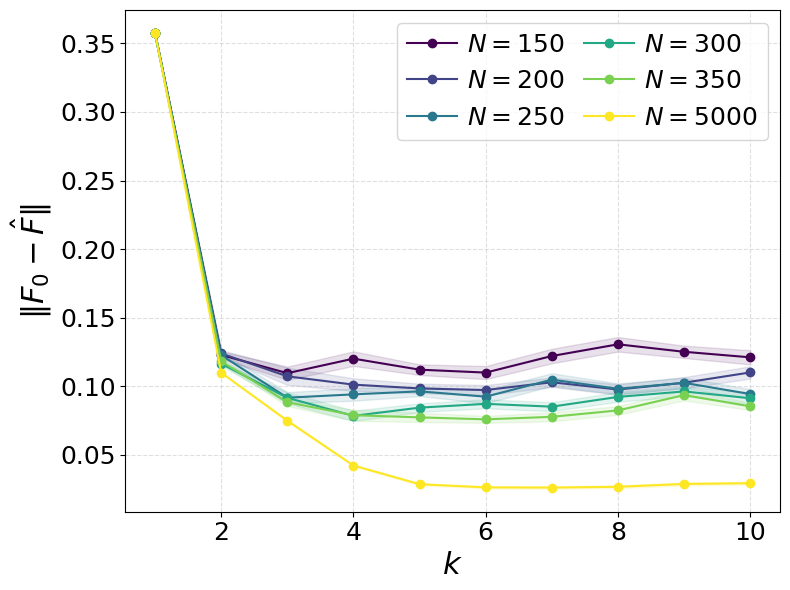

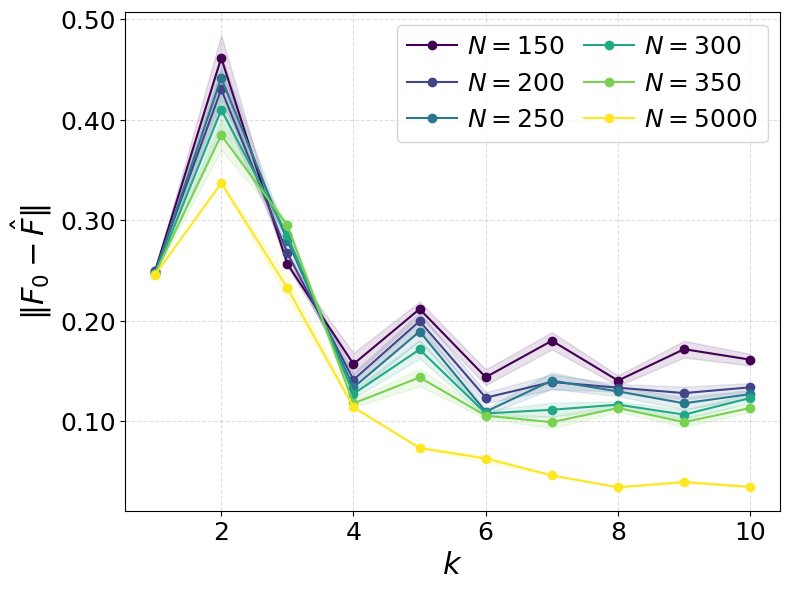

In [27]:
appendix_dists = {k: v for k, v in DISTRIBUTIONS.items() if k != 'beta'}

for dist_key, dist_cfg in appendix_dists.items():
    suffix       = dist_cfg['suffix']
    data         = np.load(f'results/data/knot_allocation_{suffix}.npz')
    total_N_list = data['total_N_values'].tolist()
    k_list       = data['k_values'].tolist()
    num_runs_    = int(data['num_runs'])
    errors       = data['errors']   # shape (len_totalN, len_k, num_runs)

    cmap   = plt.cm.viridis
    colors = [cmap(i / max(len(total_N_list) - 1, 1)) for i in range(len(total_N_list))]

    fig, ax = plt.subplots(figsize=(8, 6))
    for ti, total_N in enumerate(total_N_list):
        with np.errstate(all='ignore'):
            y_mean = np.nanmean(errors[ti, :, :], axis=1)
            y_se   = np.nanstd( errors[ti, :, :], axis=1) / np.sqrt(num_runs_)
        ax.plot(k_list, y_mean, marker='o', color=colors[ti], label=f'$N={total_N}$')
        ax.fill_between(k_list, y_mean - y_se, y_mean + y_se, alpha=0.12, color=colors[ti])

    ax.set_xlabel(r'$k$')
    ax.set_ylabel(r'$\|F_0 - \hat{F}\|$')
    # ax.set_title(dist_cfg['label'], fontsize=14)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.legend(loc='upper right', ncol=2, columnspacing=0.8, handletextpad=0.4)
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.savefig(f'results/plots/knot_allocation_{suffix}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Method Comparison

Compare three approaches for estimating an IFR CDF across a grid of $k \in \{1,\ldots,5\}$ knots and $n_i \in \{2,4,\ldots,150\}$ samples per knot:

- **Algorithm 1 (Schumaker):** solves the convex program in $t$-space with CVXPY, then applies Schumaker interpolation.
- **Discretized-IFR ($d$):** enforces IFR via bilinear (nonconvex quadratic) constraints on a fine grid with $d$ equidistant points inserted between each pair of consecutive knots, solved with Gurobi ($d \in \{2, 4, 6\}$).
- **Discretized-non-IFR:** same grid with only a monotonicity constraint — no IFR — analogous to isotonic regression; solved with Gurobi.

Figure compares $\|F_0 - \hat{F}\|$ errors; Table reports mean solution times.

### Computation

Runs 50 Monte Carlo replications per $(k, n_i)$ setting across $k \in \{1,\ldots,5\}$ and $n_i \in \{2,4,\ldots,150\}$. Per-run $\|F_0 - \hat{F}\|$ errors and solution times are saved to `numerical_results/data/method_comparison_a3_b5.npz`.

> **Note.** The Discretized-IFR and Discretized-non-IFR solvers require a Gurobi license. Algorithm 1 uses CVXPY and runs without Gurobi.

In [ ]:
from fitting import fit_cdf_nonconvex   # Gurobi-based nonconvex solver (requires Gurobi license)

np.random.seed(42)

k_values_mc   = list(range(1, 6))    # k ∈ {1, 2, 3, 4, 5} knots
n_i_values_mc = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 25, 30, 35, 40, 45, 50, 70, 90, 110, 130, 150]
num_runs_mc   = 50                   # Monte Carlo replications per (k, n_i) setting
d_values      = [2, 4, 6]           # inter-knot grid points for Discretized-IFR (Section 6.3)

# k_values_mc   = [1,3,5]    # k ∈ {1, 2, 3, 4, 5} knots
# n_i_values_mc = [2, 6, 10, 16, 25, 50, 110, 150]
# num_runs_mc   = 3                   # Monte Carlo replications per (k, n_i) setting
# d_values      = [2, 4]           # inter-knot grid points for Discretized-IFR (Section 6.3)

beta_dist_fig5 = DISTRIBUTIONS['beta']['dist']   # Beta(3,5); avoids referencing global a, b

method_names = ['algo1'] + [f'discretized_ifr_{d}' for d in d_values] + ['discretized_non_ifr']
shape        = (len(k_values_mc), len(n_i_values_mc), num_runs_mc)
all_times    = {m: np.full(shape, np.nan) for m in method_names}
all_errors   = {m: np.full(shape, np.nan) for m in method_names}

x_fine_mc    = np.linspace(l, u, 2000)
true_vals_mc = beta_dist_fig5.cdf(x_fine_mc)   # dense true CDF for Algorithm 1 L-inf error

t_start = time.perf_counter()
total = len(k_values_mc) * len(n_i_values_mc)
with tqdm(total=total, desc='(k, n_i) settings') as pbar:
    for ki, k in enumerate(k_values_mc):
        x_knots_mc = np.linspace(l, u, k + 2)[1:-1]   # k equidistant interior knots
        for ni, n_i in enumerate(n_i_values_mc):
            pbar.set_postfix(k=k, n_i=n_i)
            for run_idx in range(num_runs_mc):
                true_p      = beta_dist_fig5.cdf(x_knots_mc)
                n_trials_mc = n_i * np.ones(k, dtype=int)
                y_samp      = np.random.binomial(n_trials_mc, true_p)   # y_i ~ Binomial(n_i, F_0(x_i))

                # Discretized-IFR (Gurobi): try increasing d; break on first failure since
                # larger d makes the problem harder and will also fail
                for dval in d_values:
                    key = f'discretized_ifr_{dval}'
                    t0  = time.perf_counter()
                    try:
                        x_nc, F_nc = fit_cdf_nonconvex(x_knots_mc, n_trials_mc, y_samp, l, u, dval,
                                                        ifr_constraint=True, verbose=False, return_type='values')
                        all_errors[key][ki, ni, run_idx] = _l_inf_step_dist(x_nc, F_nc, beta_dist_fig5)
                        all_times[key][ki, ni, run_idx]  = time.perf_counter() - t0
                    except Exception:
                        break   # leave remaining d values as nan

                # Algorithm 1 (Schumaker): convex program in t-space, solved with CVXPY
                t0 = time.perf_counter()
                fitted = fit_cdf(x_knots_mc, n_trials_mc, y_samp, l, u, 'schumaker')
                elapsed = time.perf_counter() - t0
                fn = sp.lambdify(x_sym, fitted, 'numpy')
                with np.errstate(invalid='ignore', over='ignore'):
                    algo1_vals = fn(x_fine_mc)
                algo1_vals = np.where(np.isfinite(algo1_vals), algo1_vals, 1.0)   # replace sympy overflow near u with 1
                all_times['algo1'][ki, ni, run_idx]  = elapsed
                all_errors['algo1'][ki, ni, run_idx] = np.max(np.abs(np.clip(algo1_vals, 0, 1) - true_vals_mc))

                # Discretized-non-IFR (Gurobi): monotonicity only, no IFR; d=0 uses knot positions only
                try:
                    t0 = time.perf_counter()
                    x_ni, F_ni = fit_cdf_nonconvex(x_knots_mc, n_trials_mc, y_samp, l, u, 0,
                                                    ifr_constraint=False, verbose=False, return_type='values')
                    all_times['discretized_non_ifr'][ki, ni, run_idx]  = time.perf_counter() - t0
                    all_errors['discretized_non_ifr'][ki, ni, run_idx] = _l_inf_step_dist(x_ni, F_ni, beta_dist_fig5)
                except Exception:
                    pass

            pbar.update(1)

np.savez('results/data/method_comparison_beta_a3_b5.npz',
    k_values=k_values_mc, n_i_values=n_i_values_mc, num_runs=num_runs_mc, d_values=d_values,
    **{f'{m}_errors': all_errors[m] for m in method_names},
    **{f'{m}_times':  all_times[m]  for m in method_names},
)
print(f'Saved method_comparison_beta_a3_b5.npz. Total time: {time.perf_counter() - t_start:.1f}s')

### Plotting $\|F_0 - \hat{F}\|$

Loads `numerical_results/data/method_comparison_a3_b5.npz` and can be run independently. Left panel: mean $L_\infty$ error vs $n_i$ at the middle fixed $k$; right panel: vs $k$ at the largest fixed $n_i$. Shaded bands show $\pm 1$ standard error.

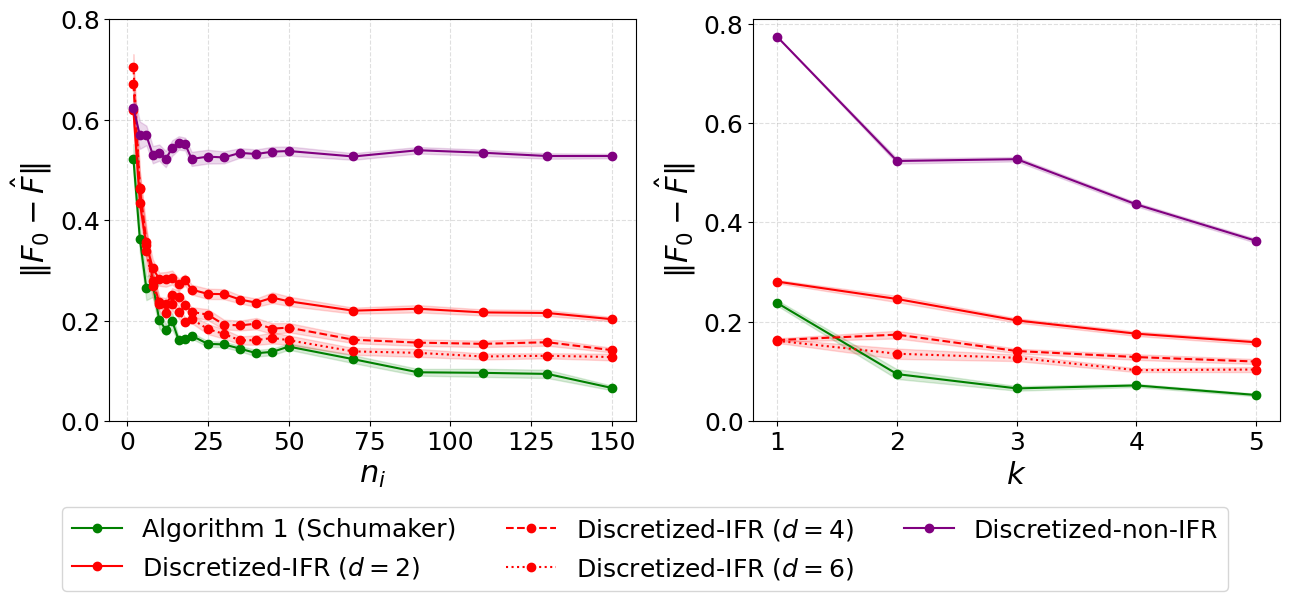

In [28]:
data = np.load('results/data/method_comparison_beta_a3_b5.npz')

k_values   = data['k_values'].tolist()
n_i_values = data['n_i_values'].tolist()
num_runs_  = int(data['num_runs'])
d_values   = data['d_values'].tolist()

# left panel: fix k = 3 (middle of k ∈ {1..5}); right panel: fix n_i = 150 (largest)
ki_fix  = len(k_values) // 2
k_fix   = k_values[ki_fix]      # k = 3
ni_fix  = -1
n_i_fix = n_i_values[ni_fix]    # n_i = 150

nc_linestyles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1))]
method_keys   = ['algo1'] + [f'discretized_ifr_{d}' for d in d_values] + ['discretized_non_ifr']
method_labels = (['Algorithm 1 (Schumaker)']
                 + [f'Discretized-IFR ($d = {d}$)' for d in d_values]
                 + ['Discretized-non-IFR'])
colors     = ['green'] + ['red'] * len(d_values) + ['purple']
linestyles = ['-'] + nc_linestyles[:len(d_values)] + ['-']

raw_errors = {m: data[f'{m}_errors'] for m in method_keys}   # shape (len_k, len_n_i, num_runs)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# left panel: vary n_i at fixed k = 3
ax = axes[0]
for m, label, c, ls in zip(method_keys, method_labels, colors, linestyles):
    slice_ = raw_errors[m][ki_fix, :, :]   # shape (len_n_i, num_runs)
    with np.errstate(all='ignore'):
        y_mean = np.nanmean(slice_, axis=1)
        y_se   = np.nanstd( slice_, axis=1) / np.sqrt(num_runs_)
    ax.plot(n_i_values, y_mean, marker='o', color=c, linestyle=ls, label=label)
    ax.fill_between(n_i_values, y_mean - y_se, y_mean + y_se, alpha=0.15, color=c)   # ±1 SE band
ax.set_xlabel(r'$n_i$')
ax.set_ylabel(r'$\|F_0 - \hat{F}\|$')
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8])
ax.grid(True, linestyle='--', alpha=0.4)

# right panel: vary k at fixed n_i = 150
ax = axes[1]
for m, label, c, ls in zip(method_keys, method_labels, colors, linestyles):
    slice_ = raw_errors[m][:, ni_fix, :]   # shape (len_k, num_runs)
    with np.errstate(all='ignore'):
        y_mean = np.nanmean(slice_, axis=1)
        y_se   = np.nanstd( slice_, axis=1) / np.sqrt(num_runs_)
    ax.plot(k_values, y_mean, marker='o', color=c, linestyle=ls, label=label)
    ax.fill_between(k_values, y_mean - y_se, y_mean + y_se, alpha=0.15, color=c)   # ±1 SE band
ax.set_xlabel(r'$k$')
ax.set_ylabel(r'$\|F_0 - \hat{F}\|$')
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8])
ax.grid(True, linestyle='--', alpha=0.4)

handles, labels_ = axes[0].get_legend_handles_labels()
plt.subplots_adjust(bottom=0.82)   # reserve vertical space below the panels for the shared legend
fig.legend(handles, labels_, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.015))
plt.tight_layout(rect=[0, 0.15, 1, 1])
plt.savefig('results/plots/method_comparison_beta_lines.png', dpi=150, bbox_inches='tight')
plt.show()

### Solution Times

Loads `numerical_results/data/method_comparison_a3_b5.npz` and can be run independently. Displays mean solution time per run (seconds), $\pm$ standard deviation, and failure count in brackets. A failure occurs when Gurobi does not reach a feasible solution within the 600-second time limit; failed runs are replaced by 600 s in the mean. Also writes a LaTeX table to `numerical_results/plots/method_comparison_table.tex`.

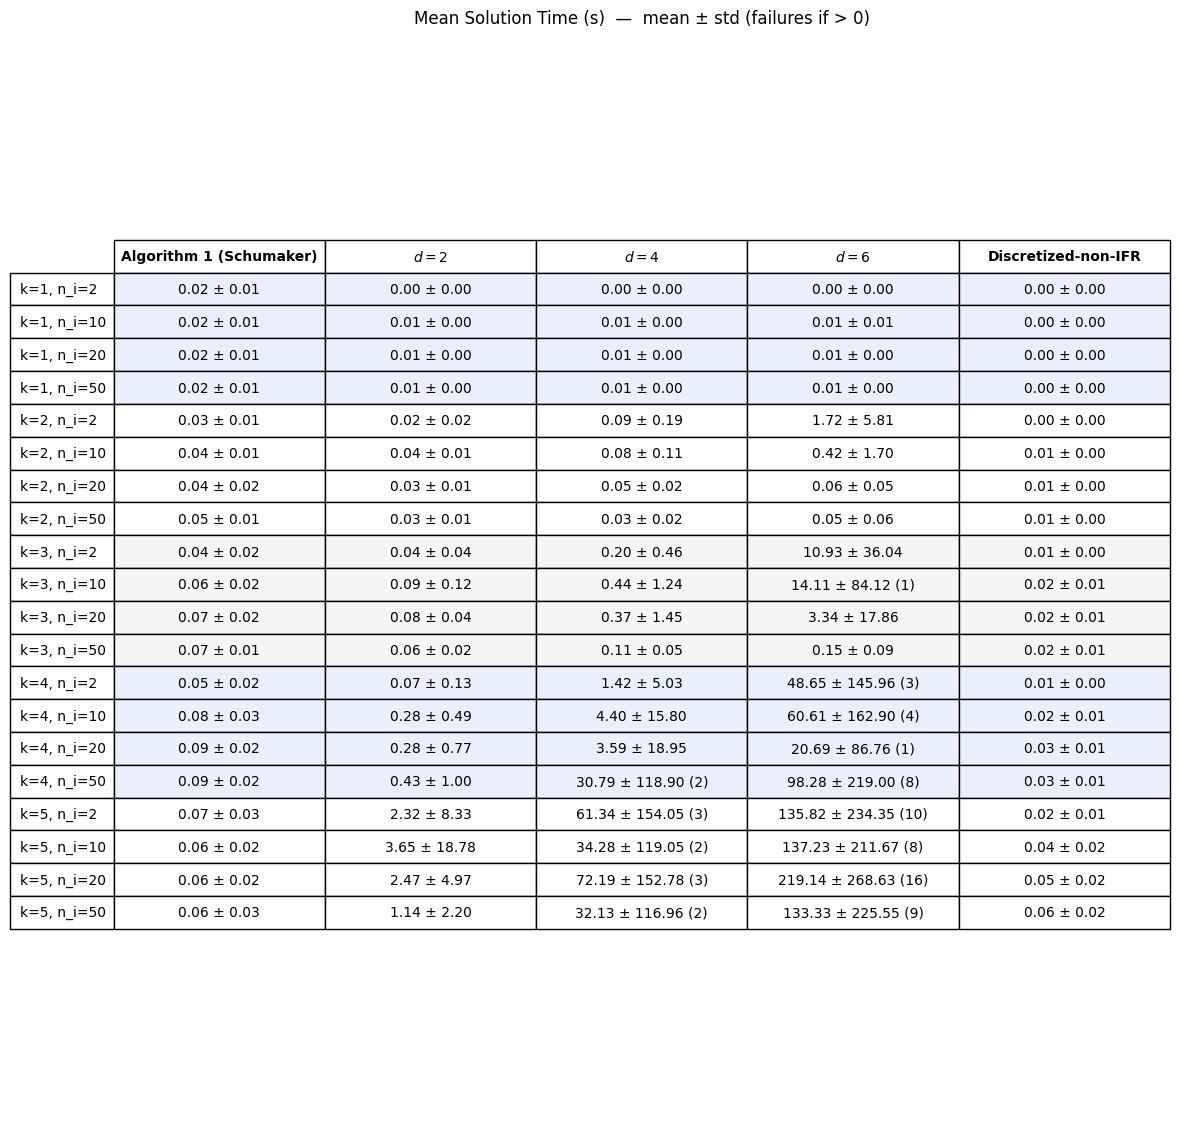

Saved method_comparison_table.png and method_comparison_beta_table.tex


In [29]:
data = np.load('results/data/method_comparison_beta_a3_b5.npz')

k_values   = data['k_values'].tolist()
n_i_values = data['n_i_values'].tolist()
d_values   = data['d_values'].tolist()
num_runs_  = int(data['num_runs'])

# k and n_i indices to display in the table (Table 1 from the paper)
k_indices   = [0, 1, 2, 3, 4]    # all k ∈ {1, 2, 3, 4, 5}
n_i_indices = [0, 4, 9, 15]       # n_i ∈ {2, 10, 20, 50}

method_keys = ['algo1'] + [f'discretized_ifr_{d}' for d in d_values] + ['discretized_non_ifr']
col_headers = (['Algorithm 1 (Schumaker)']
               + [f'$d={d}$' for d in d_values]
               + ['Discretized-non-IFR'])
raw_times = {m: data[f'{m}_times'] for m in method_keys}

shade = ['#eaf0fb', '#ffffff', '#f5f5f5']   # alternating row shading per k group

cell_text  = []
row_labels = []
row_colors = []

for gi, ki in enumerate(k_indices):
    k = k_values[ki]
    for ni in n_i_indices:
        n_i = n_i_values[ni]
        row = []
        for m in method_keys:
            t_raw  = raw_times[m][ki, ni, :]
            n_fail = int(np.sum(np.isnan(t_raw)))
            t_vals = np.where(np.isnan(t_raw), 600.0, t_raw)
            mean_t = np.mean(t_vals)
            std_t  = np.std(t_vals) if len(t_vals) > 1 else 0.0
            cell = f'{mean_t:.2f} ± {std_t:.2f}'
            if n_fail > 0:
                cell += f' ({n_fail})'
            row.append(cell)
        cell_text.append(row)
        row_labels.append(f'k={k}, n_i={n_i}')
        row_colors.append([shade[gi % len(shade)]] * len(method_keys))

n_rows = len(k_indices) * len(n_i_indices)
fig, ax = plt.subplots(figsize=(12, 0.5 + n_rows * 0.55))
ax.axis('off')

tbl = ax.table(
    cellText=cell_text,
    rowLabels=row_labels,
    colLabels=col_headers,
    cellLoc='center',
    loc='center',
    cellColours=row_colors,
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.6)

for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(fontweight='bold')

ax.set_title('Mean Solution Time (s)  —  mean ± std (failures if > 0)', fontsize=12, pad=12)
plt.tight_layout()
plt.savefig('results/plots/method_comparison_beta_table.png', dpi=150, bbox_inches='tight')
plt.show()

# --- LaTeX table ---
n_per_group = len(n_i_indices)

lines = [
    r'\begin{table}[h]',
    r'\centering',
    r'\small',
    r'\begin{tabular}{cc|c|ccc|c}',
    r'\toprule',
    r' & & \multicolumn{1}{c|}{\textbf{Algorithm 1}} & \multicolumn{3}{c|}{\textbf{Discretized-IFR}} & \multicolumn{1}{c}{\textbf{Discretized-}} \\',
    r'\textbf{$k$} & \textbf{$n_i$} & \textbf{(Schumaker)} & \textbf{$d=2$} & \textbf{$d=4$} & \textbf{$d=6$} & \textbf{non-IFR} \\',
    r'\midrule',
]

for row_idx, row in enumerate(cell_text):
    group_idx  = row_idx // n_per_group
    within_idx = row_idx %  n_per_group
    ki  = k_indices[group_idx]
    k   = k_values[ki]
    n_i = n_i_values[n_i_indices[within_idx]]
    if within_idx == 0 and row_idx != 0:
        lines.append(r'\midrule')
    k_cell    = str(k) if within_idx == n_per_group // 2 else ''
    latex_row = [c.replace('±', r'$\pm$') for c in row]
    lines.append(f'{k_cell} & {n_i} & ' + ' & '.join(latex_row) + r' \\')

lines += [
    r'\bottomrule', r'\end{tabular}',
    r'\caption{\normalfont Mean solution times in seconds for the estimation methods under the ground-truth cdf $F_0\sim\text{Beta}(3,5)$. Cells report mean $\pm$ standard deviation; parenthetical values report the number of failures and are shown only when positive.}',
    r'\label{tab:solve_times}', r'\end{table}',
]

with open('results/plots/method_comparison_table.tex', 'w') as f:
    f.write('\n'.join(lines))
print('Saved method_comparison_table.png and method_comparison_beta_table.tex')

## Appendix — Method Comparison for Additional Distributions

Replicates experiment for Truncated Normal, Truncated Gamma, and Truncated Weibull. Top row: $\|F_0 - \hat{F}\|$ vs $n_i$ at fixed $k$ (middle value). Bottom row: $\|F_0 - \hat{F}\|$ vs $k$ at fixed $n_i$ (largest value).

In [ ]:
from fitting import fit_cdf_nonconvex

np.random.seed(0)

k_values_mc   = list(range(1, 6))
n_i_values_mc = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 25, 30, 35, 40, 45, 50, 70, 90, 110, 130, 150]
num_runs_mc   = 25   # reduce for testing
d_values      = [2, 4, 6]   # inter-knot grid points for Discretized-IFR (higher d → finer grid, harder problem)

# k_values_mc   = [1,3,5]    # k ∈ {1, 2, 3, 4, 5} knots
# n_i_values_mc = [2, 6, 10, 16, 25, 50, 110, 150]
# num_runs_mc   = 3                   # Monte Carlo replications per (k, n_i) setting
# d_values      = [2, 4]           # inter-knot grid points for Discretized-IFR (Section 6.3)


appendix_dists = {k: v for k, v in DISTRIBUTIONS.items() if k != 'beta'}
x_fine_fig5   = np.linspace(l, u, 2000)

method_names = ['algo1'] + [f'discretized_ifr_{d}' for d in d_values] + ['discretized_non_ifr']

t_start = time.perf_counter()
for dist_key, dist_cfg in appendix_dists.items():
    dist         = dist_cfg['dist']
    true_vals_mc = dist.cdf(x_fine_fig5)   # pre-compute true CDF on dense grid once per distribution

    shape      = (len(k_values_mc), len(n_i_values_mc), num_runs_mc)
    all_times  = {m: np.full(shape, np.nan) for m in method_names}
    all_errors = {m: np.full(shape, np.nan) for m in method_names}

    with tqdm(total=len(k_values_mc) * len(n_i_values_mc), desc=dist_key) as pbar:
        for ki, k in enumerate(k_values_mc):
            x_knots_mc = np.linspace(l, u, k + 2)[1:-1]   # k equidistant interior knots
            for ni, n_i in enumerate(n_i_values_mc):
                pbar.set_postfix(k=k, n_i=n_i)
                for run_idx in range(num_runs_mc):
                    true_p      = dist.cdf(x_knots_mc)
                    n_trials_mc = n_i * np.ones(k, dtype=int)
                    y_samp      = np.random.binomial(n_trials_mc, true_p)   # y_i ~ Binomial(n_i, F_0(x_i))

                    # Discretized-IFR (Gurobi): try d values in increasing order; break on first failure
                    # because larger d makes the bilinear program harder and will also fail
                    for dval in d_values:
                        key = f'discretized_ifr_{dval}'
                        t0  = time.perf_counter()
                        try:
                            x_nc, F_nc = fit_cdf_nonconvex(x_knots_mc, n_trials_mc, y_samp, l, u, dval,
                                                            ifr_constraint=True, verbose=False, return_type='values')
                            all_errors[key][ki, ni, run_idx] = _l_inf_step_dist(x_nc, F_nc, dist)
                            all_times[key][ki, ni, run_idx]  = time.perf_counter() - t0
                        except Exception:
                            break   # leave remaining d values as nan and move on

                    # Algorithm 1 (Schumaker / CVXPY): convex program in t-space
                    t0     = time.perf_counter()
                    fitted = fit_cdf(x_knots_mc, n_trials_mc, y_samp, l, u, 'schumaker')
                    fn     = sp.lambdify(x_sym, fitted, 'numpy')
                    with np.errstate(invalid='ignore', over='ignore'):
                        algo1_vals = fn(x_fine_fig5)
                    algo1_vals = np.where(np.isfinite(algo1_vals), algo1_vals, 1.0)   # overflow near u means F ≈ 1
                    all_times['algo1'][ki, ni, run_idx]  = time.perf_counter() - t0
                    all_errors['algo1'][ki, ni, run_idx] = np.max(np.abs(np.clip(algo1_vals, 0, 1) - true_vals_mc))

                    # Discretized-non-IFR (Gurobi): monotonicity only, no IFR; d=0 uses knots only
                    try:
                        t0 = time.perf_counter()
                        x_ni, F_ni = fit_cdf_nonconvex(x_knots_mc, n_trials_mc, y_samp, l, u, 0,
                                                        ifr_constraint=False, verbose=False, return_type='values')
                        all_times['discretized_non_ifr'][ki, ni, run_idx]  = time.perf_counter() - t0
                        all_errors['discretized_non_ifr'][ki, ni, run_idx] = _l_inf_step_dist(x_ni, F_ni, dist)
                    except Exception:
                        pass

                pbar.update(1)

    suffix = dist_cfg['suffix']
    np.savez(f'results/data/method_comparison_{suffix}.npz',
        k_values=k_values_mc, n_i_values=n_i_values_mc, num_runs=num_runs_mc, d_values=d_values,
        **{f'{m}_errors': all_errors[m] for m in method_names},
        **{f'{m}_times':  all_times[m]  for m in method_names},
    )
    print(f'Saved method_comparison_{suffix}_v2.npz')

print(f'Total time: {time.perf_counter() - t_start:.1f}s')

### Plotting

Loads the pre-computed `.npz` files from the computation cell above and produces the 2×3 appendix figure. Top row shows $\|F_0 - \hat{F}\|$ vs $n_i$ at the middle fixed $k$; bottom row shows $\|F_0 - \hat{F}\|$ vs $k$ at the largest fixed $n_i$. Can be run independently of the computation cell.

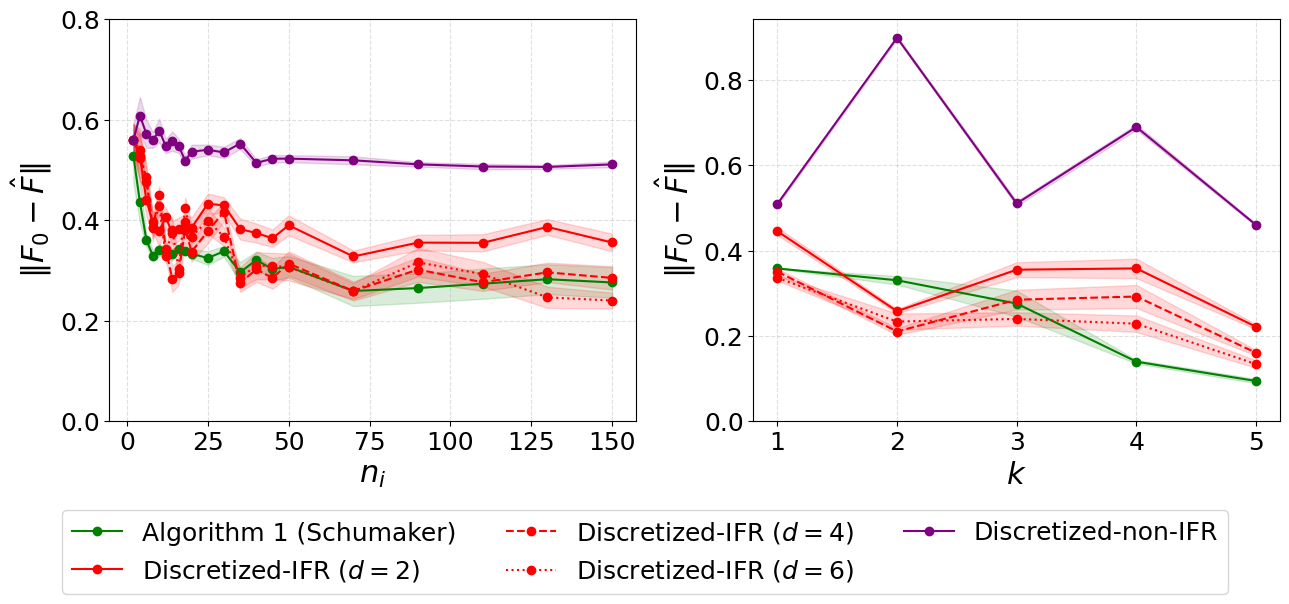

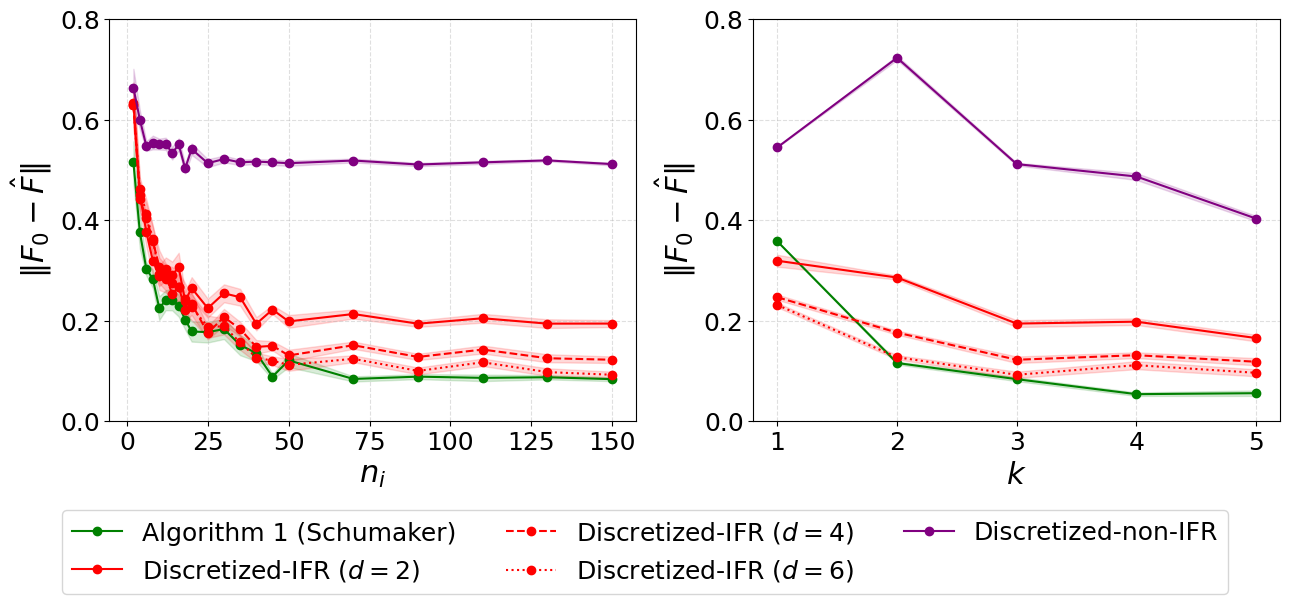

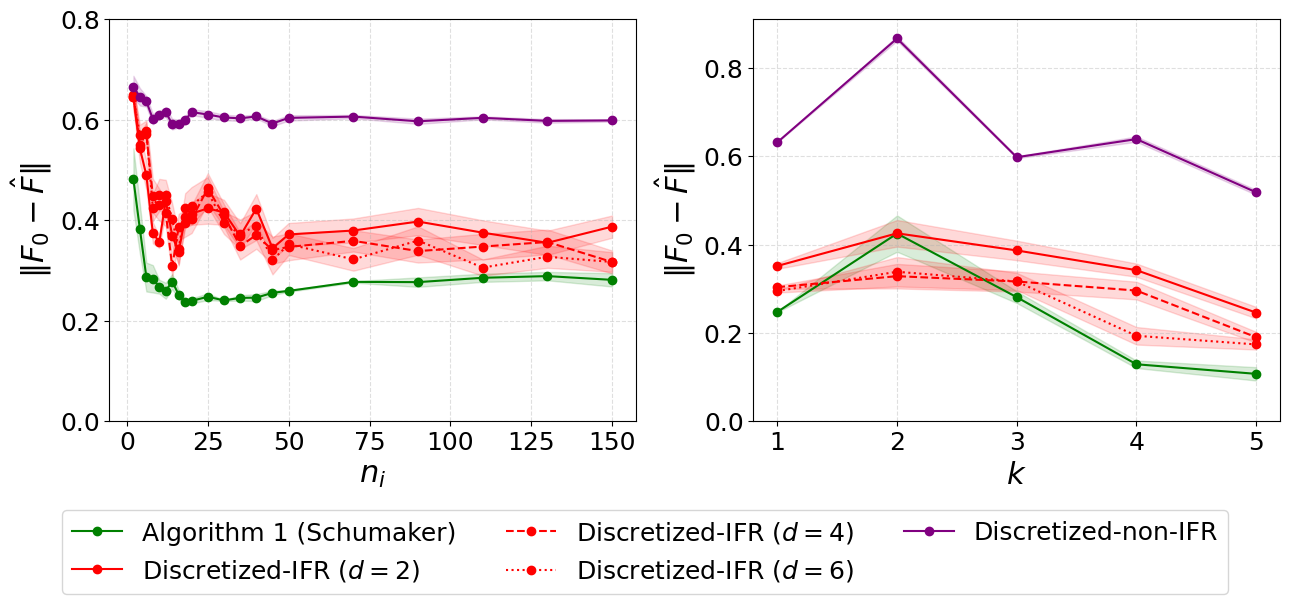

In [30]:
appendix_dists  = {k: v for k, v in DISTRIBUTIONS.items() if k != 'beta'}
d_values        = [2, 4, 6]
nc_linestyles   = ['-', '--', ':', '-.', (0, (3, 1, 1, 1))]
method_keys     = ['algo1'] + [f'discretized_ifr_{d}' for d in d_values] + ['discretized_non_ifr']
method_labels   = (['Algorithm 1 (Schumaker)']
                   + [f'Discretized-IFR ($d={d}$)' for d in d_values]
                   + ['Discretized-non-IFR'])
colors_mc       = ['green'] + ['red'] * len(d_values) + ['purple']
linestyles_mc   = ['-'] + nc_linestyles[:len(d_values)] + ['-']

for dist_key, dist_cfg in appendix_dists.items():
    suffix     = dist_cfg['suffix']
    data       = np.load(f'results/data/method_comparison_{suffix}.npz')
    k_values   = data['k_values'].tolist()
    n_i_values = data['n_i_values'].tolist()
    num_runs_  = int(data['num_runs'])
    raw_errors = {m: data[f'{m}_errors'] for m in method_keys}

    ki_fix = len(k_values) // 2   # middle k (k=3 when k ∈ {1..5})
    ni_fix = -1                    # largest n_i in sweep

    fig, axes = plt.subplots(1, 2, figsize=(13, 6))

    # LHS: vary n_i at fixed k
    ax = axes[0]
    for m, label, c, ls in zip(method_keys, method_labels, colors_mc, linestyles_mc):
        slice_ = raw_errors[m][ki_fix, :, :]   # shape (len_n_i, num_runs)
        with np.errstate(all='ignore'):
            y_mean = np.nanmean(slice_, axis=1)
            y_se   = np.nanstd( slice_, axis=1) / np.sqrt(num_runs_)
        ax.plot(n_i_values, y_mean, marker='o', color=c, linestyle=ls, label=label)
        ax.fill_between(n_i_values, y_mean - y_se, y_mean + y_se, alpha=0.15, color=c)
    ax.set_xlabel(r'$n_i$')
    ax.set_ylabel(r'$\|F_0 - \hat{F}\|$')
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8])
    ax.grid(True, linestyle='--', alpha=0.4)

    # RHS: vary k at fixed n_i
    ax = axes[1]
    for m, label, c, ls in zip(method_keys, method_labels, colors_mc, linestyles_mc):
        slice_ = raw_errors[m][:, ni_fix, :]   # shape (len_k, num_runs)
        with np.errstate(all='ignore'):
            y_mean = np.nanmean(slice_, axis=1)
            y_se   = np.nanstd( slice_, axis=1) / np.sqrt(num_runs_)
        ax.plot(k_values, y_mean, marker='o', color=c, linestyle=ls, label=label)
        ax.fill_between(k_values, y_mean - y_se, y_mean + y_se, alpha=0.15, color=c)
    ax.set_xlabel(r'$k$')
    ax.set_ylabel(r'$\|F_0 - \hat{F}\|$')
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8])
    ax.grid(True, linestyle='--', alpha=0.4)

    handles, labels_ = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout(rect=[0, 0.15, 1, 1])
    plt.savefig(f'results/plots/method_comparison_appendix_{suffix}.png', dpi=150, bbox_inches='tight')
    plt.show()